# SATX House Hack Model — Exploratory Data Analysis

This notebook examines every data source the scoring model relies on.

**The goal is not to produce charts for their own sake.** Each section answers a specific question that either validates a model assumption or challenges it:

| Source | Key Question |
|--------|-------------|
| ZHVI (home values) | Where does the $450k ceiling cut? Is the stability metric meaningful? |
| ZORI (rents) | Where does the 6.5% yield floor land? Are there natural market clusters? |
| Census (demographics) | Are the owner-occ and income filter thresholds defensible? |
| SAPD Crime (CFS) | How much of 5.3M calls is actually crime? Does the Problem filter hold up? |
| Cross-source | How many ZIPs survive each stage? Where does the funnel narrow? |

---

**Run order:** Top to bottom. Each section auto-fetches data via `data_loader.py` (TTL-cached in `.cache/`) and does not depend on the main pipeline having run first.

**No manual downloads required** — all data sources are fetched automatically on first run.

## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
SRC  = ROOT / 'src'
sys.path.insert(0, str(SRC))

from config import (THRESHOLDS, CRIME_PERCENTILE_CUTOFF, YIELD_CAP, MIN_POPULATION_FOR_CRIME,
                    ZHVI_STABILITY_YEARS, VIOLENT_CRIME_PROBLEMS, MAX_COMMUTE_MINS)
from data_loader import load_zhvi, load_zori, load_census_acs, load_crime_data, load_zhvf

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

BAMC_COLOR    = '#c0392b'
PASS_COLOR    = '#27ae60'
FAIL_COLOR    = '#e74c3c'
NEUTRAL_COLOR = '#2980b9'
WARN_COLOR    = '#f39c12'

print(f'Root: {ROOT}')

Root: /Users/asan/workspace/personnal/satx_house_hack_model


---
## 1. Zillow Home Values (ZHVI)

**Source:** `zillow_zhvi_zip.csv` — monthly median home values by ZIP, SA metro.

**Two things this file powers:**
1. `median_home_value` — most recent value, used in the $450k ceiling filter and yield denominator
2. `zhvi_cov` — Coefficient of Variation over 5 years of monthly values, the price stability score

**Questions:**
- Where does the $450k ceiling cut in the distribution? Which specific ZIPs does it remove?
- What does appreciation look like across ZIPs over the last 3 years?
- Does the CoV stability metric spread ZIPs out meaningfully, or do they all cluster together?

In [2]:
zhvi_raw = load_zhvi()
zhvi_sa  = zhvi_raw[zhvi_raw['Metro'].str.contains('San Antonio', na=False)].copy()
zhvi_sa['zip'] = zhvi_sa['RegionName'].str.zfill(5)

date_cols = sorted([c for c in zhvi_sa.columns if c[:4].isdigit()])
zhvi_sa['current_value'] = pd.to_numeric(zhvi_sa[date_cols[-1]], errors='coerce')
zhvi_sa.dropna(subset=['current_value'], inplace=True)

print(f'SA ZIPs: {len(zhvi_sa)}')
print(f'Monthly data range: {date_cols[0]} to {date_cols[-1]} ({len(date_cols)} months)')
print(f'\nHome value distribution:')
print(zhvi_sa['current_value'].describe().apply(lambda x: f'${x:,.0f}'))

SA ZIPs: 106
Monthly data range: 2000-01-31 to 2026-04-30 (316 months)

Home value distribution:
count        $106
mean     $325,209
std      $148,413
min      $113,610
25%      $219,362
50%      $285,409
75%      $423,995
max      $925,954
Name: current_value, dtype: str


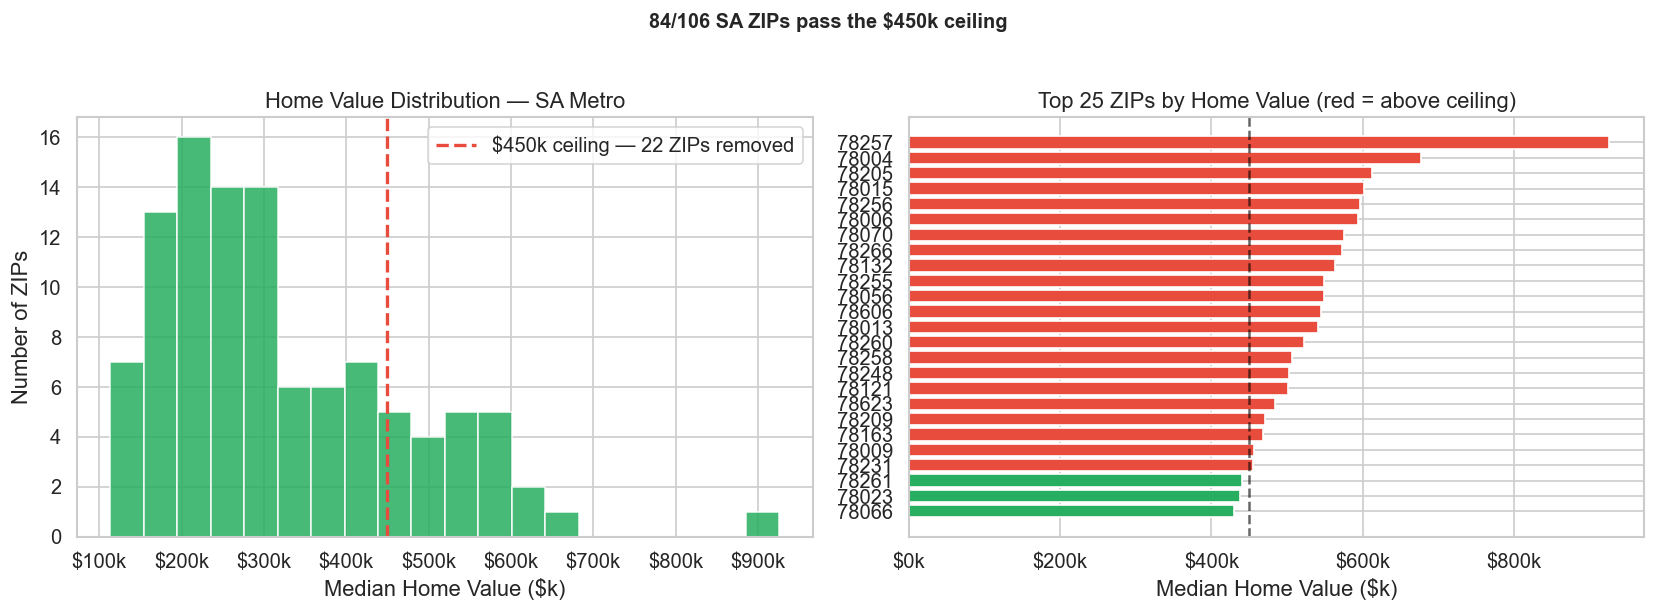

ZIPs above ceiling: ['78257', '78004', '78205', '78015', '78256', '78006', '78070', '78266', '78132', '78255', '78056', '78606', '78013', '78260', '78258', '78248', '78121', '78623', '78209', '78163', '78009', '78231']


In [3]:
# 1.1 Distribution with $450k ceiling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_val = THRESHOLDS['max_home_value']
n_pass  = (zhvi_sa['current_value'] <= max_val).sum()
n_fail  = (zhvi_sa['current_value'] >  max_val).sum()

ax = axes[0]
ax.hist(zhvi_sa['current_value'] / 1e3, bins=20, color=PASS_COLOR, edgecolor='white', alpha=0.85)
ax.axvline(max_val / 1e3, color=FAIL_COLOR, linewidth=2, linestyle='--',
           label=f'${max_val/1e3:.0f}k ceiling — {n_fail} ZIPs removed')
ax.set_xlabel('Median Home Value ($k)')
ax.set_ylabel('Number of ZIPs')
ax.set_title('Home Value Distribution — SA Metro')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))

ax2 = axes[1]
sorted_df = zhvi_sa.sort_values('current_value', ascending=False).head(25)
bar_colors = [FAIL_COLOR if v > max_val else PASS_COLOR for v in sorted_df['current_value']]
ax2.barh(sorted_df['zip'], sorted_df['current_value'] / 1e3, color=bar_colors, edgecolor='white')
ax2.axvline(max_val / 1e3, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
ax2.set_xlabel('Median Home Value ($k)')
ax2.set_title('Top 25 ZIPs by Home Value (red = above ceiling)')
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))

plt.suptitle(f'{n_pass}/{len(zhvi_sa)} SA ZIPs pass the ${max_val/1e3:.0f}k ceiling',
             y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

above = sorted_df[sorted_df['current_value'] > max_val]['zip'].tolist()
print(f"ZIPs above ceiling: {above}")

**What to look for:** If ZIPs cluster just *above* the $450k line, the threshold may be cutting too aggressively and worth raising slightly. If the ZIPs above it are all clearly premium (Stone Oak, The Dominion, Boerne), the filter is doing its job.

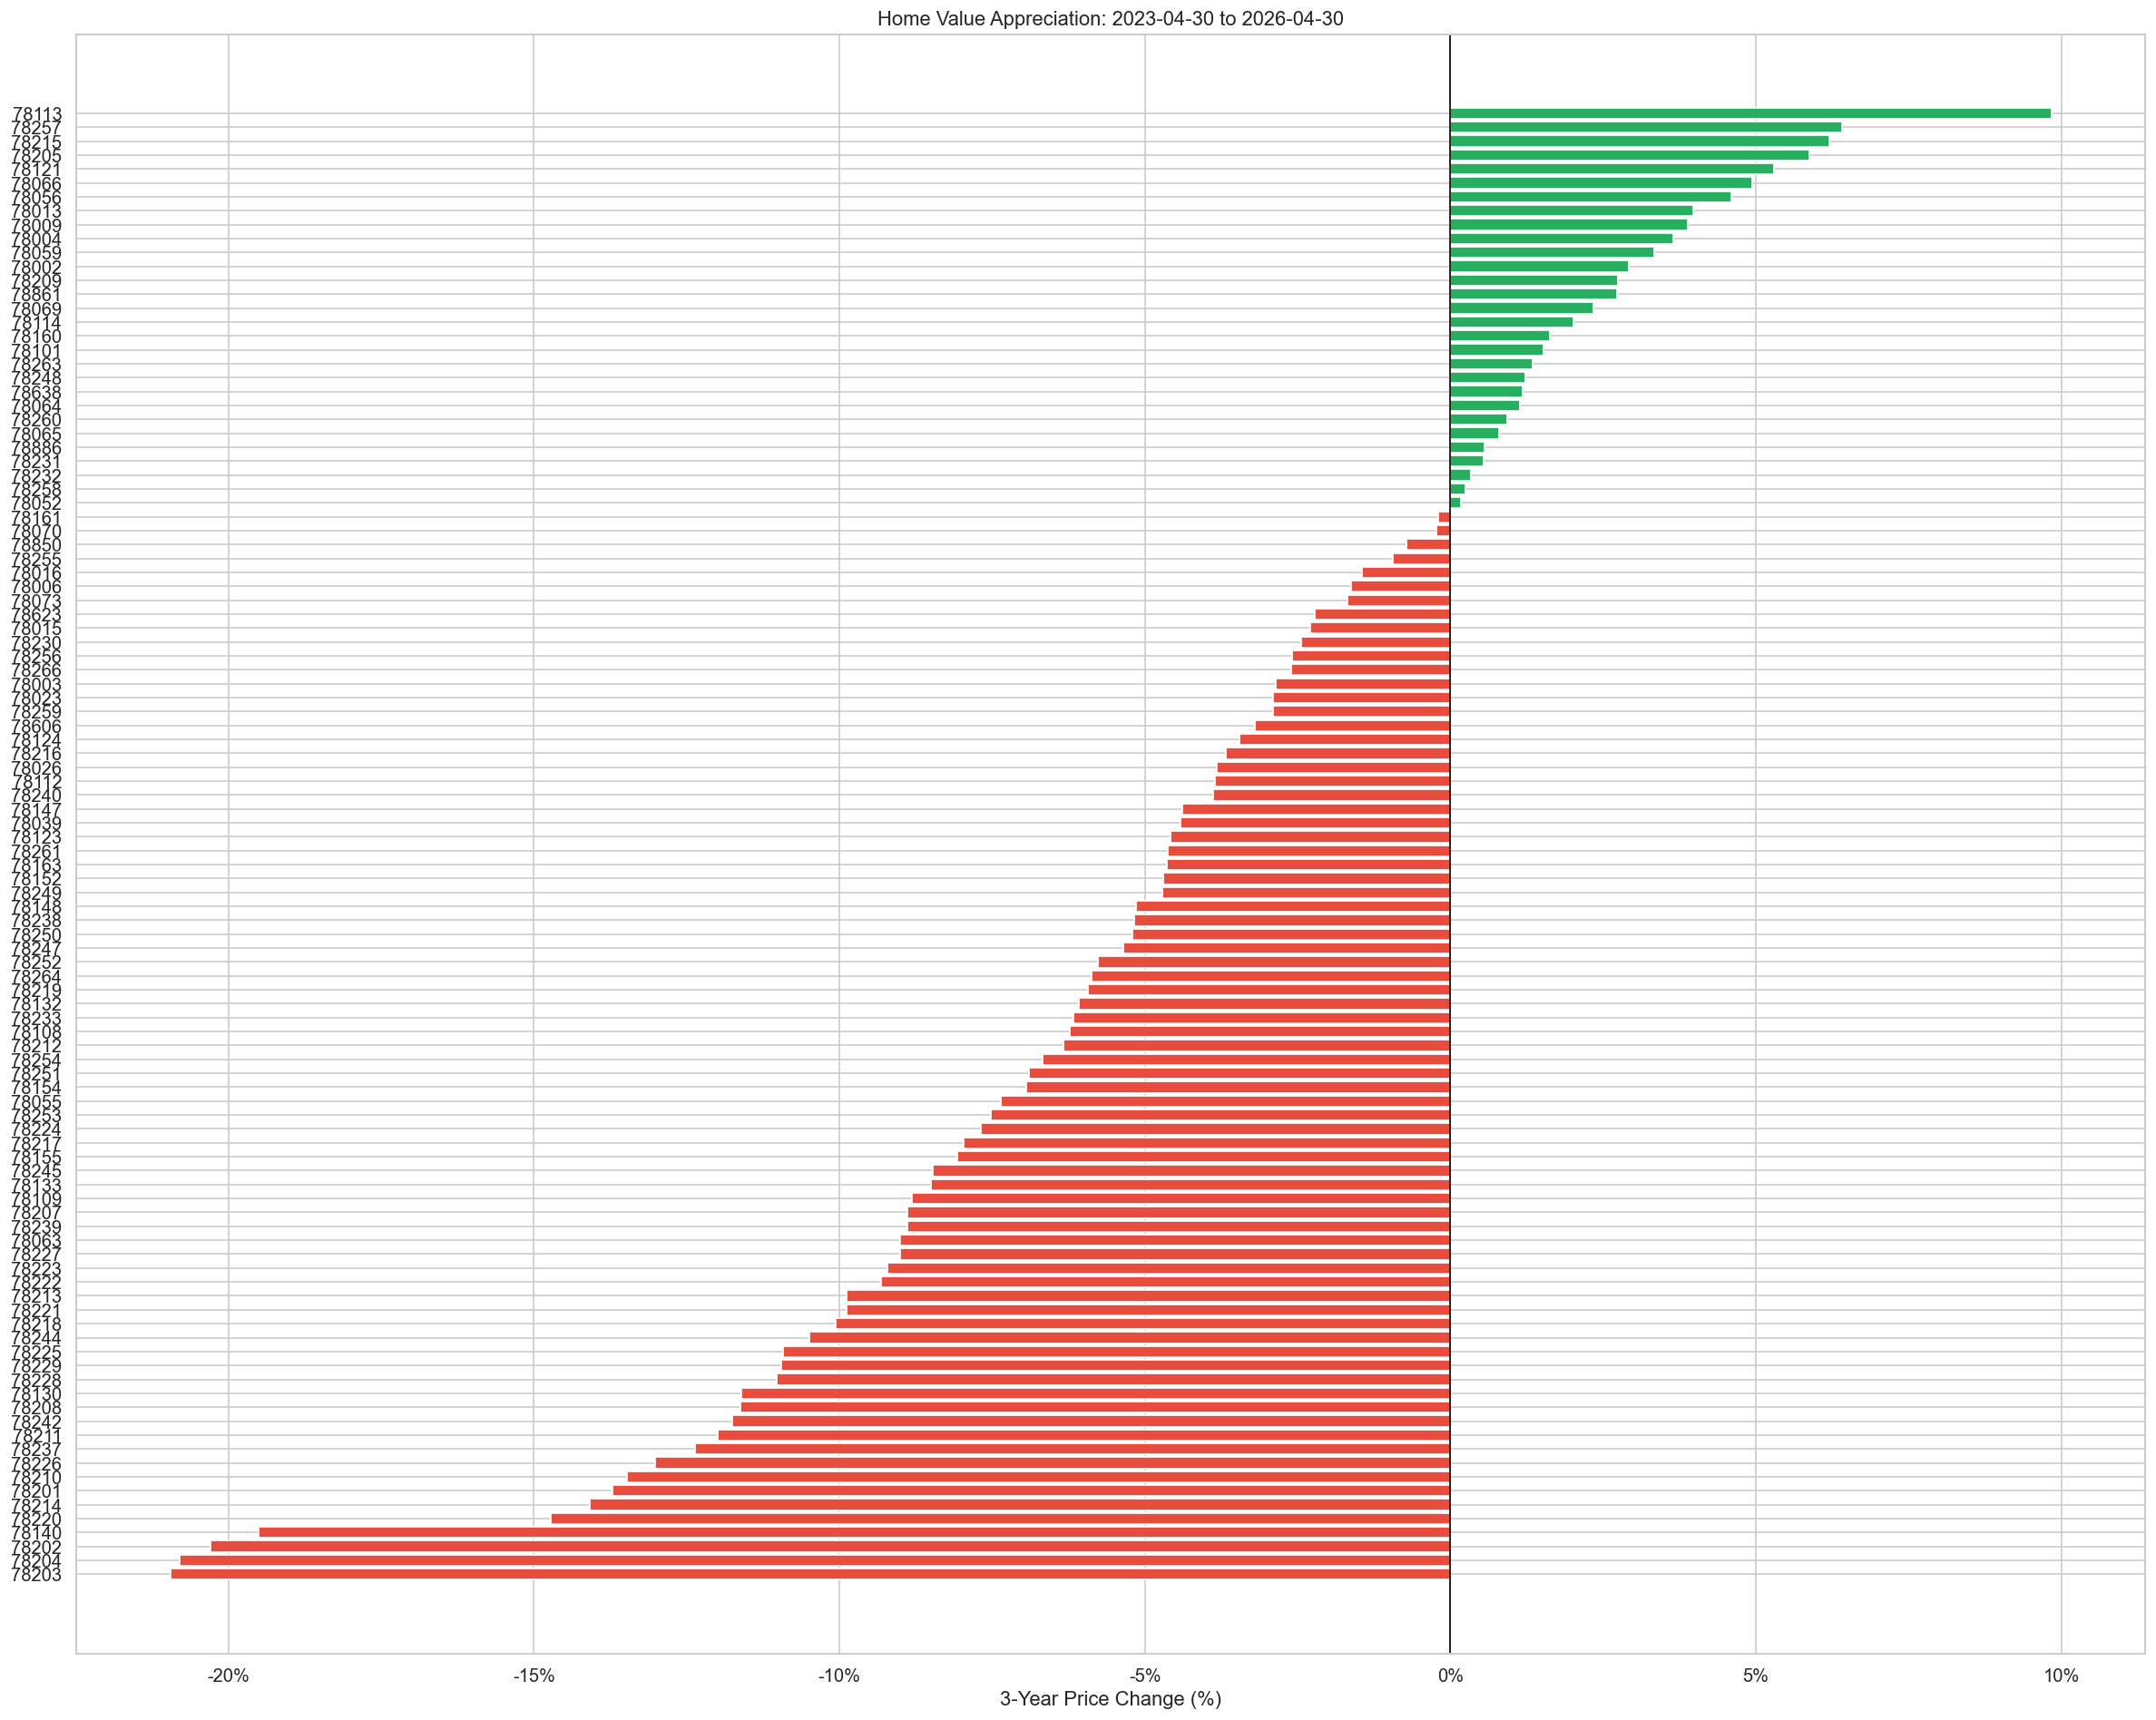

Median 3-year appreciation: -4.6%
ZIPs with negative 3yr return: 77

Top 5 by appreciation:
  zip  current_value  pct_change_3yr
78113  424424.726441        9.836451
78257  925954.374330        6.410076
78215  422705.423470        6.205562
78205  611768.380374        5.872352
78121  501532.160429        5.292752


In [4]:
# 1.2 3-year price appreciation by ZIP
months_3yr = 36
if len(date_cols) >= months_3yr + 1:
    col_3yr_ago = date_cols[-(months_3yr + 1)]
    zhvi_sa['value_3yr_ago']  = pd.to_numeric(zhvi_sa[col_3yr_ago], errors='coerce')
    zhvi_sa['pct_change_3yr'] = (zhvi_sa['current_value'] - zhvi_sa['value_3yr_ago']) / zhvi_sa['value_3yr_ago'] * 100
    zhvi_sa.dropna(subset=['pct_change_3yr'], inplace=True)

    fig, ax = plt.subplots(figsize=(20, 16))
    sorted_appr  = zhvi_sa.sort_values('pct_change_3yr')
    bar_colors_a = [PASS_COLOR if v >= 0 else FAIL_COLOR for v in sorted_appr['pct_change_3yr']]
    ax.barh(sorted_appr['zip'], sorted_appr['pct_change_3yr'], color=bar_colors_a, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('3-Year Price Change (%)')
    ax.set_title(f'Home Value Appreciation: {col_3yr_ago} to {date_cols[-1]}')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    plt.tight_layout()
    plt.show()

    print(f"Median 3-year appreciation: {zhvi_sa['pct_change_3yr'].median():.1f}%")
    print(f"ZIPs with negative 3yr return: {(zhvi_sa['pct_change_3yr'] < 0).sum()}")
    print(f"\nTop 5 by appreciation:")
    print(zhvi_sa.nlargest(5, 'pct_change_3yr')[['zip','current_value','pct_change_3yr']].to_string(index=False))
else:
    print("Not enough data for 3-year comparison.")

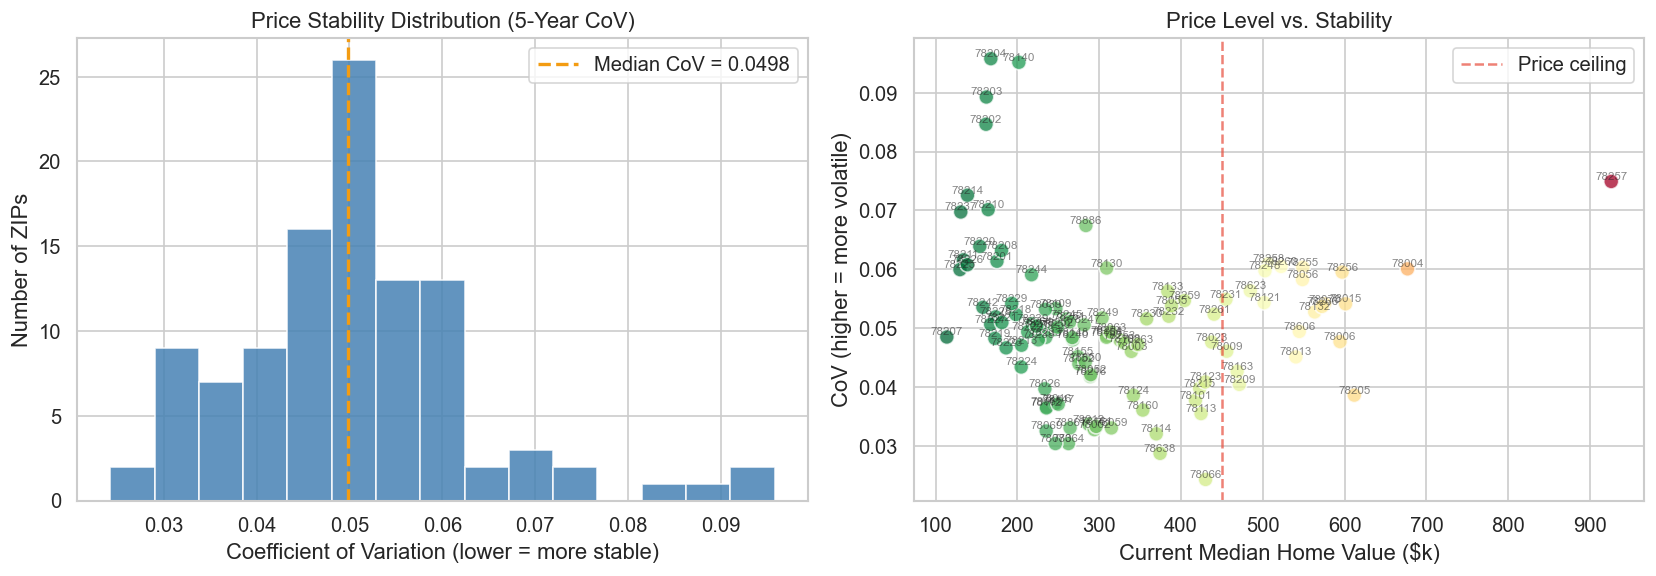

Most stable (lowest CoV):
  zip  current_value      cov
78066  429930.676235 0.024241
78638  374323.527536 0.028679
78064  262301.556378 0.030346
78073  246383.559857 0.030349
78114  369678.891271 0.032004

Least stable (highest CoV):
  zip  current_value      cov
78204  167414.430168 0.095787
78140  201689.615552 0.095169
78203  161928.093057 0.089267
78202  161517.979352 0.084637
78257  925954.374330 0.074907


In [5]:
# 1.3 Price stability — Coefficient of Variation
n_months = ZHVI_STABILITY_YEARS * 12
stability_cols = date_cols[-n_months:] if len(date_cols) >= n_months else date_cols

price_data = zhvi_sa.set_index('zip')[stability_cols].apply(pd.to_numeric, errors='coerce')
zhvi_sa_cov = (price_data.std(axis=1) / price_data.mean(axis=1)).rename('cov')
zhvi_sa = zhvi_sa.set_index('zip').join(zhvi_sa_cov).reset_index()
zhvi_sa.dropna(subset=['cov'], inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(zhvi_sa['cov'], bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(zhvi_sa['cov'].median(), color=WARN_COLOR, linewidth=2, linestyle='--',
           label=f"Median CoV = {zhvi_sa['cov'].median():.4f}")
ax.set_xlabel('Coefficient of Variation (lower = more stable)')
ax.set_ylabel('Number of ZIPs')
ax.set_title(f'Price Stability Distribution ({ZHVI_STABILITY_YEARS}-Year CoV)')
ax.legend()

ax2 = axes[1]
ax2.scatter(zhvi_sa['current_value'] / 1e3, zhvi_sa['cov'],
            c=zhvi_sa['current_value'], cmap='RdYlGn_r', alpha=0.75, edgecolors='white', s=80)
for _, row in zhvi_sa.iterrows():
    ax2.annotate(row['zip'], (row['current_value']/1e3, row['cov']),
                 fontsize=7, alpha=0.55, ha='center', va='bottom')
ax2.axvline(THRESHOLDS['max_home_value'] / 1e3, color=FAIL_COLOR,
            linestyle='--', linewidth=1.5, alpha=0.7, label='Price ceiling')
ax2.set_xlabel('Current Median Home Value ($k)')
ax2.set_ylabel('CoV (higher = more volatile)')
ax2.set_title('Price Level vs. Stability')
ax2.legend()

plt.tight_layout()
plt.show()

print("Most stable (lowest CoV):")
print(zhvi_sa.nsmallest(5, 'cov')[['zip','current_value','cov']].to_string(index=False))
print("\nLeast stable (highest CoV):")
print(zhvi_sa.nlargest(5, 'cov')[['zip','current_value','cov']].to_string(index=False))

**What to look for:** A wide spread in CoV is good — the stability score is discriminating meaningfully. If everything clusters tightly (e.g., all CoV between 0.08–0.12), the stability dimension adds little signal and its 10% weight may not be doing much. Also check: do high-CoV ZIPs show the highest 3-year appreciation? That would confirm the classic volatility/return tradeoff.

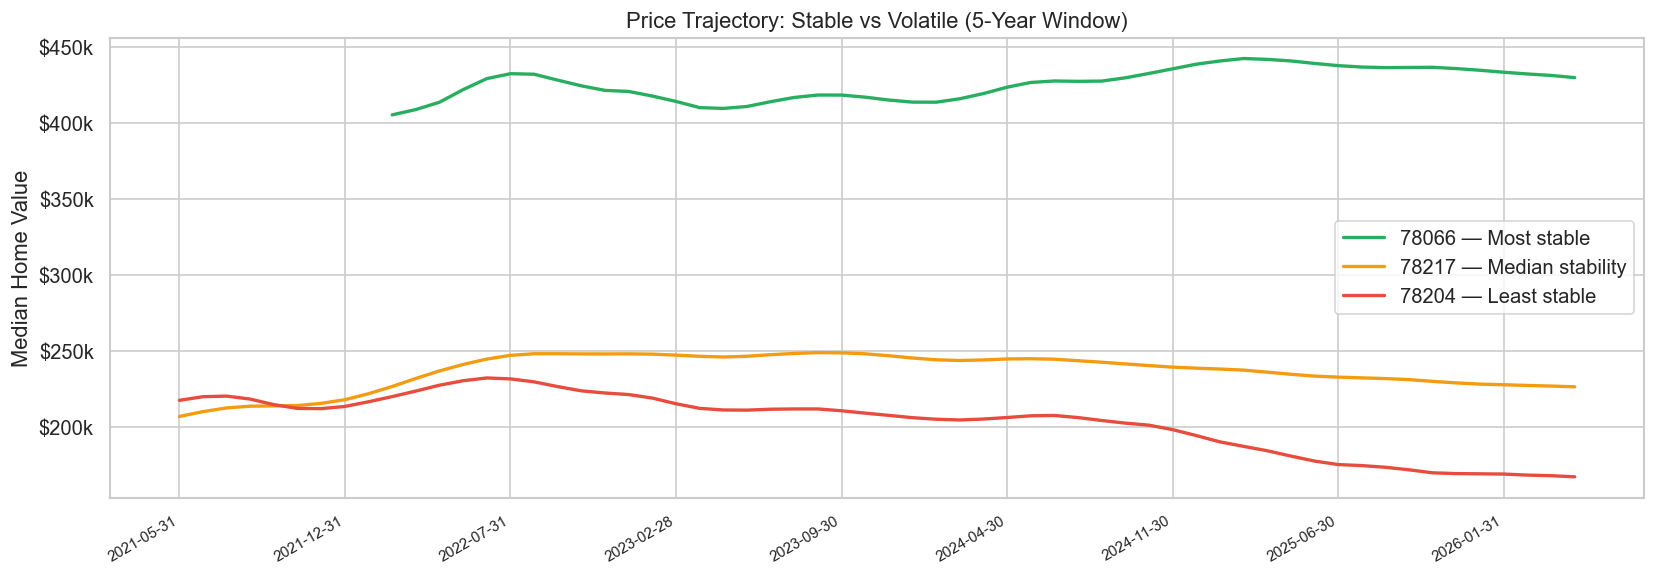

In [6]:
# 1.4 Price time-series: stable vs volatile ZIPs
most_stable  = zhvi_sa.nsmallest(1, 'cov')['zip'].values[0]
least_stable = zhvi_sa.nlargest(1, 'cov')['zip'].values[0]
median_zip   = zhvi_sa.iloc[(zhvi_sa['cov'] - zhvi_sa['cov'].median()).abs().argsort()[:1]]['zip'].values[0]

highlight = [(most_stable, 'Most stable', PASS_COLOR),
             (median_zip,  'Median stability', WARN_COLOR),
             (least_stable,'Least stable', FAIL_COLOR)]

fig, ax = plt.subplots(figsize=(14, 5))
for zip_code, label, color in highlight:
    row = zhvi_sa[zhvi_sa['zip'] == zip_code]
    if len(row) == 0: continue
    values = pd.to_numeric(row[stability_cols].iloc[0], errors='coerce')
    ax.plot(range(len(stability_cols)), values / 1e3,
            label=f'{zip_code} — {label}', color=color, linewidth=2)

tick_step = max(1, len(stability_cols) // 8)
ax.set_xticks(range(0, len(stability_cols), tick_step))
ax.set_xticklabels([stability_cols[i] for i in range(0, len(stability_cols), tick_step)],
                    rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.set_ylabel('Median Home Value')
ax.set_title(f'Price Trajectory: Stable vs Volatile ({ZHVI_STABILITY_YEARS}-Year Window)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Zillow Rents (ZORI) & Yield Analysis

**Source:** `zillow_zori_zip.csv` — monthly median asking rent by ZIP, SA metro.

**What this powers:** `median_rent` is combined with `median_home_value` to compute gross yield. The 6.5% yield floor is the hard filter most likely to be the model's tightest gate.

**Questions:**
- Where does the 6.5% yield floor actually land in the SA distribution?
- Are there ZIPs just below the floor that are borderline cuts vs. genuinely unviable?
- Is there a clean inverse relationship between home price and yield? (There should be.)
- Are asking rents trending up or down in the ZIPs that pass the floor?

SA ZIPs with rent data: 67

Rent distribution:
count       $67
mean     $1,454
std        $243
min      $1,043
25%      $1,285
50%      $1,448
75%      $1,569
max      $2,239
Name: median_rent, dtype: str

ZIPs with both price + rent: 66
Pass yield floor (4.5%): 50 | Fail: 16


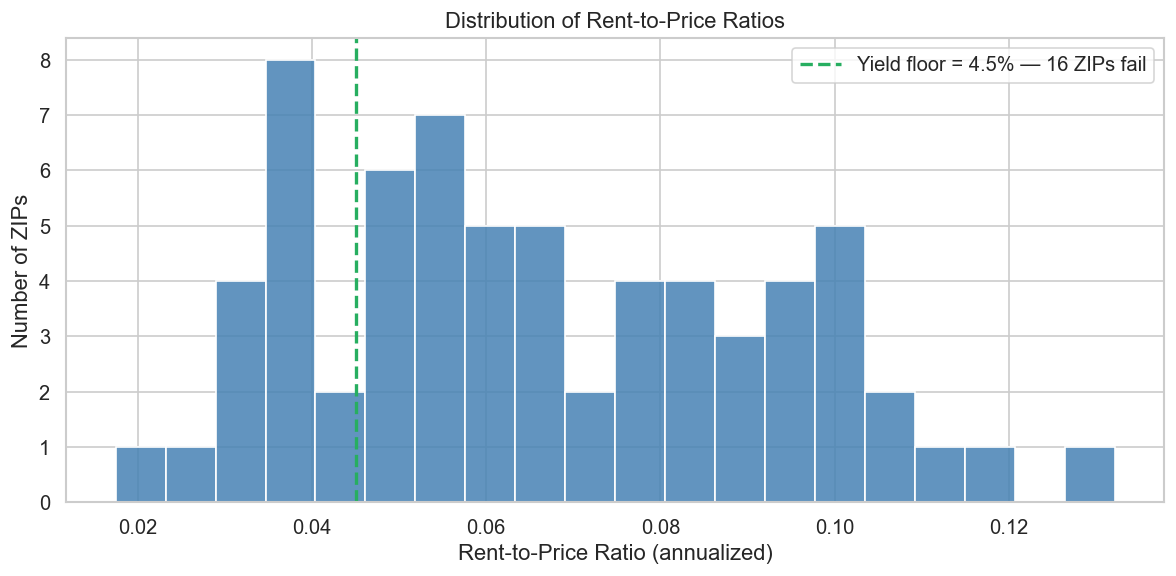

In [7]:
zori_raw = load_zori()
zori_sa  = zori_raw[zori_raw['Metro'].str.contains('San Antonio', na=False)].copy()
zori_sa['zip'] = zori_sa['RegionName'].str.zfill(5)

date_cols_zori = sorted([c for c in zori_sa.columns if c[:4].isdigit()])
zori_sa['median_rent'] = pd.to_numeric(zori_sa[date_cols_zori[-1]], errors='coerce')
zori_sa.dropna(subset=['median_rent'], inplace=True)

print(f'SA ZIPs with rent data: {len(zori_sa)}')
print(f'\nRent distribution:')
print(zori_sa['median_rent'].describe().apply(lambda x: f'${x:,.0f}'))

# Merge with ZHVI to compute yield
merged_yield = zhvi_sa[['zip','current_value','cov']].merge(
    zori_sa[['zip','median_rent']], on='zip', how='inner')
merged_yield['rent_to_price'] = (merged_yield['median_rent'] * 12) / merged_yield['current_value']

yield_floor  = THRESHOLDS['min_rent_to_price']
n_pass_yield = (merged_yield['rent_to_price'] >= yield_floor).sum()
n_fail_yield = (merged_yield['rent_to_price'] <  yield_floor).sum()

print(f'\nZIPs with both price + rent: {len(merged_yield)}')
print(f'Pass yield floor ({yield_floor:.1%}): {n_pass_yield} | Fail: {n_fail_yield}')

plt.figure(figsize=(10, 5))
sns.histplot(merged_yield['rent_to_price'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(yield_floor, color=PASS_COLOR, linewidth=2, linestyle='--',
            label=f'Yield floor = {yield_floor:.1%} — {n_fail_yield} ZIPs fail')
plt.xlabel('Rent-to-Price Ratio (annualized)')
plt.ylabel('Number of ZIPs')
plt.title('Distribution of Rent-to-Price Ratios')
plt.legend()
plt.tight_layout()
plt.show()

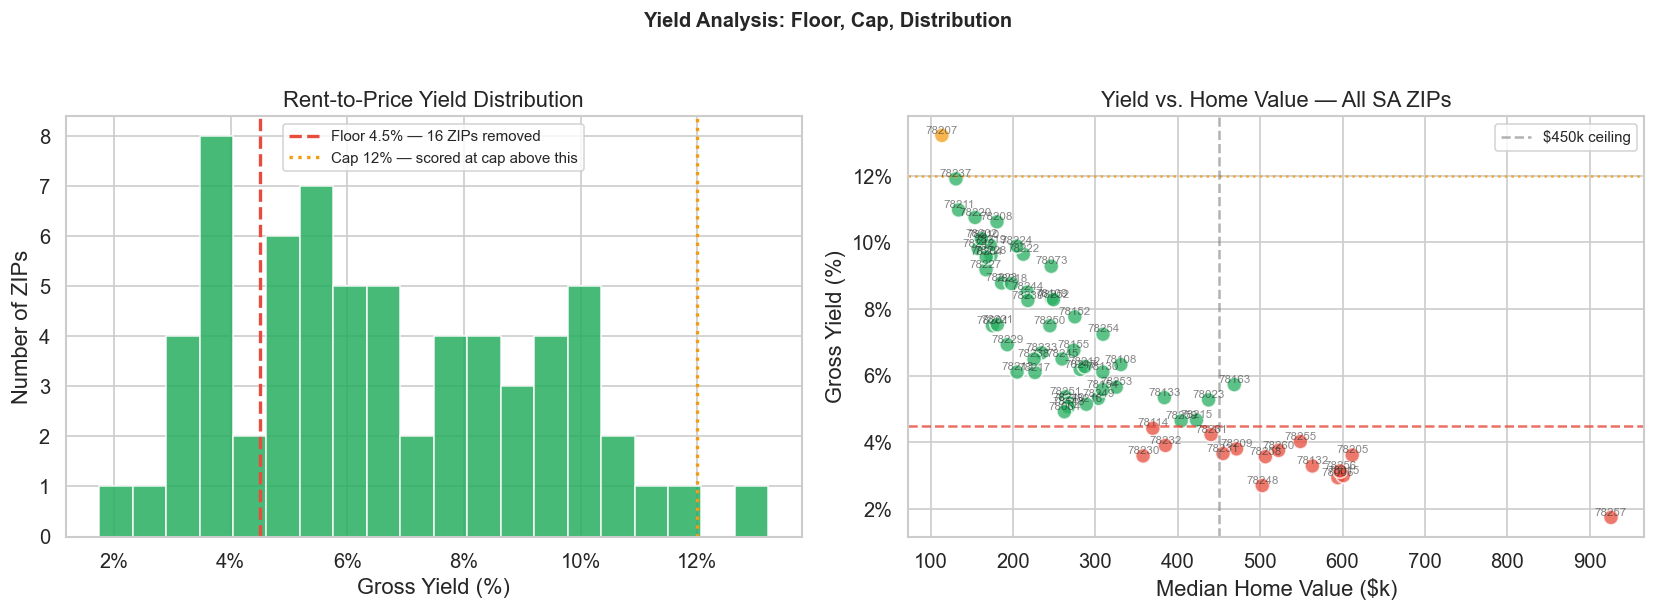


ZIPs within 15% below floor (borderline — review before accepting cut):
  zip  current_value  median_rent  rent_to_price
78114  369678.891271  1362.500000       0.044228
78261  440362.644839  1554.094487       0.042349
78255  548792.667163  1840.947222       0.040254
78232  385005.293466  1253.504924       0.039070


In [8]:
# 2.1 Yield distribution with floor and cap annotations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(merged_yield['rent_to_price'] * 100, bins=20,
        color=PASS_COLOR, edgecolor='white', alpha=0.85)
ax.axvline(yield_floor * 100, color=FAIL_COLOR, linewidth=2, linestyle='--',
           label=f'Floor {yield_floor:.1%} — {n_fail_yield} ZIPs removed')
ax.axvline(YIELD_CAP * 100, color=WARN_COLOR, linewidth=2, linestyle=':',
           label=f'Cap {YIELD_CAP:.0%} — scored at cap above this')
ax.set_xlabel('Gross Yield (%)')
ax.set_ylabel('Number of ZIPs')
ax.set_title('Rent-to-Price Yield Distribution')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=9)

ax2 = axes[1]
pt_colors = [
    FAIL_COLOR if v < yield_floor else WARN_COLOR if v > YIELD_CAP else PASS_COLOR
    for v in merged_yield['rent_to_price']
]
ax2.scatter(merged_yield['current_value'] / 1e3, merged_yield['rent_to_price'] * 100,
            c=pt_colors, alpha=0.75, edgecolors='white', s=80)
for _, row in merged_yield.iterrows():
    ax2.annotate(row['zip'], (row['current_value']/1e3, row['rent_to_price']*100),
                 fontsize=7, alpha=0.55, ha='center', va='bottom')
ax2.axhline(yield_floor * 100, color=FAIL_COLOR, linewidth=1.5, linestyle='--', alpha=0.8)
ax2.axhline(YIELD_CAP * 100,   color=WARN_COLOR, linewidth=1.5, linestyle=':', alpha=0.8)
ax2.axvline(THRESHOLDS['max_home_value'] / 1e3, color='gray',
            linewidth=1.5, linestyle='--', alpha=0.6, label='$450k ceiling')
ax2.set_xlabel('Median Home Value ($k)')
ax2.set_ylabel('Gross Yield (%)')
ax2.set_title('Yield vs. Home Value — All SA ZIPs')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.legend(fontsize=9)

plt.suptitle('Yield Analysis: Floor, Cap, Distribution', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Borderline ZIPs: within 15% of floor — most sensitive to threshold choice
borderline = merged_yield[
    (merged_yield['rent_to_price'] >= yield_floor * 0.85) &
    (merged_yield['rent_to_price'] <  yield_floor)
].sort_values('rent_to_price', ascending=False)
print(f"\nZIPs within 15% below floor (borderline — review before accepting cut):")
if len(borderline) > 0:
    print(borderline[['zip','current_value','median_rent','rent_to_price']].to_string(index=False))
else:
    print("None ==> All ZIPs either clearly pass or fail the yield floor.")

**What to look for:** The scatter plot should show a clean downward slope — expensive homes yield less. ZIPs that break that pattern (cheap home, low yield OR expensive home, high yield) are anomalies worth investigating. The borderline table shows ZIPs where a small threshold adjustment would change the outcome — if you recognize any as genuinely viable neighborhoods, lower the floor to `0.065`.

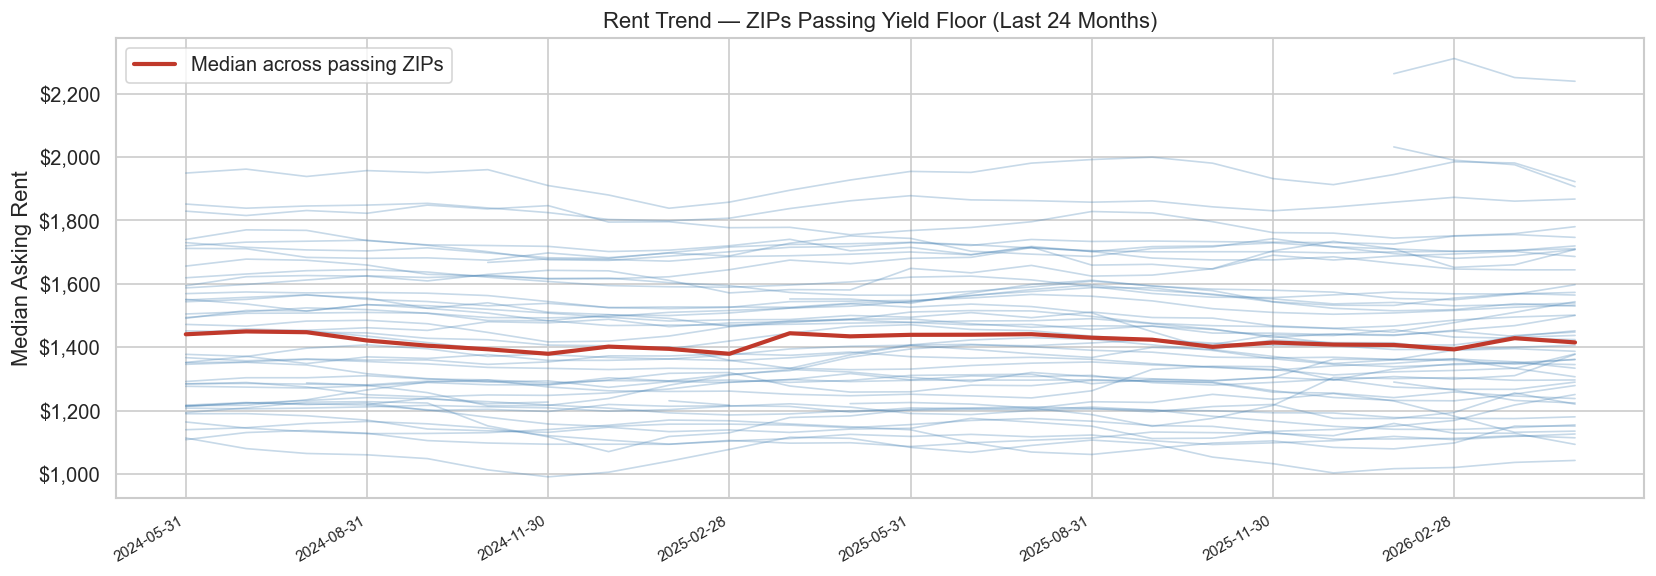

6-month rent drift summary:
count    59.0%
mean      0.3%
std       3.6%
min      -9.3%
25%      -1.4%
50%      -0.1%
75%       1.4%
max      12.4%
Name: rent_6m_pct, dtype: str

ZIPs with rent decline over 6 months: 31

Top 5 ZIPs by 6-month rent growth:
  zip  rent_6m_pct
78207    12.350453
78237    10.303868
78210     6.471788
78220     6.456506
78155     5.161272


In [9]:
# 2.2 Rent trend — last 24 months for yield-passing ZIPs
passing_zips   = merged_yield[merged_yield['rent_to_price'] >= yield_floor]['zip'].tolist()
plot_rent_data = zori_sa[zori_sa['zip'].isin(passing_zips)].copy()
recent_rent    = date_cols_zori[-24:]

fig, ax = plt.subplots(figsize=(14, 5))
for _, row in plot_rent_data.iterrows():
    vals = pd.to_numeric(row[recent_rent], errors='coerce')
    ax.plot(range(len(recent_rent)), vals, alpha=0.3, linewidth=1, color='steelblue')

median_trend = plot_rent_data[recent_rent].apply(pd.to_numeric, errors='coerce').median()
ax.plot(range(len(recent_rent)), median_trend, color=BAMC_COLOR,
        linewidth=2.5, label='Median across passing ZIPs', zorder=5)

tick_step = max(1, len(recent_rent) // 8)
ax.set_xticks(range(0, len(recent_rent), tick_step))
ax.set_xticklabels([recent_rent[i] for i in range(0, len(recent_rent), tick_step)],
                    rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylabel('Median Asking Rent')
ax.set_title('Rent Trend — ZIPs Passing Yield Floor (Last 24 Months)')
ax.legend()
plt.tight_layout()
plt.show()

# 6-month rent drift
if len(date_cols_zori) >= 7:
    rent_6m_ago = pd.to_numeric(zori_sa[date_cols_zori[-7]], errors='coerce')
    rent_now    = pd.to_numeric(zori_sa[date_cols_zori[-1]],  errors='coerce')
    zori_sa['rent_6m_pct'] = (rent_now - rent_6m_ago) / rent_6m_ago * 100
    print("6-month rent drift summary:")
    print(zori_sa['rent_6m_pct'].describe().apply(lambda x: f'{x:.1f}%'))

    print(f"\nZIPs with rent decline over 6 months: {(zori_sa['rent_6m_pct'] < 0).sum()}")
    print(f"\nTop 5 ZIPs by 6-month rent growth:")
    print(zori_sa.nlargest(5, 'rent_6m_pct')[['zip','rent_6m_pct']].to_string(index=False))
else:
    print("Not enough data for 6-month rent drift analysis.")

---
## 3. Census — Owner-Occupancy, Income & Population

**Source:** `census_acs_raw.csv` — ACS 5-year survey, Texas ZIPs.

**What this powers:**
- `owner_occ_pct` — filtered to 50%–80%, scored at 20% weight
- `median_hh_income` — $45k hard filter (tenant quality screen)
- `population` — crime per-1k denominator (dropped after merge)

**Questions:**
- Do the 50%/80% owner-occupancy bounds actually fit where SA's market clusters?
- Is $45k a meaningful income dividing line in SA, or does it cut too aggressively?
- Do income and owner-occupancy track together? (They usually do — low income / low owner-occ often come together.)

In [10]:
census_raw = load_census_acs()
census_raw['zip'] = census_raw['zip'].astype(str).str.zfill(5)
for col in ['owner_occ_count','total_housing','median_hh_income','population']:
    if col in census_raw.columns:
        census_raw[col] = pd.to_numeric(census_raw[col], errors='coerce')
census_raw.loc[census_raw['median_hh_income'] < 0, 'median_hh_income'] = None
census_raw['owner_occ_pct'] = census_raw['owner_occ_count'] / census_raw['total_housing']

census_valid = census_raw[census_raw['total_housing'] > 0].copy()
sa_zips      = set(zhvi_sa['zip'])
census_sa    = census_valid[census_valid['zip'].isin(sa_zips)].copy()

print(f'SA ZIPs with Census data: {len(census_sa)}')
print(f'\nMissing data by column:')
print(census_sa[['owner_occ_pct','median_hh_income','population']].isna().sum())

SA ZIPs with Census data: 106

Missing data by column:
owner_occ_pct       0
median_hh_income    0
population          0
dtype: int64


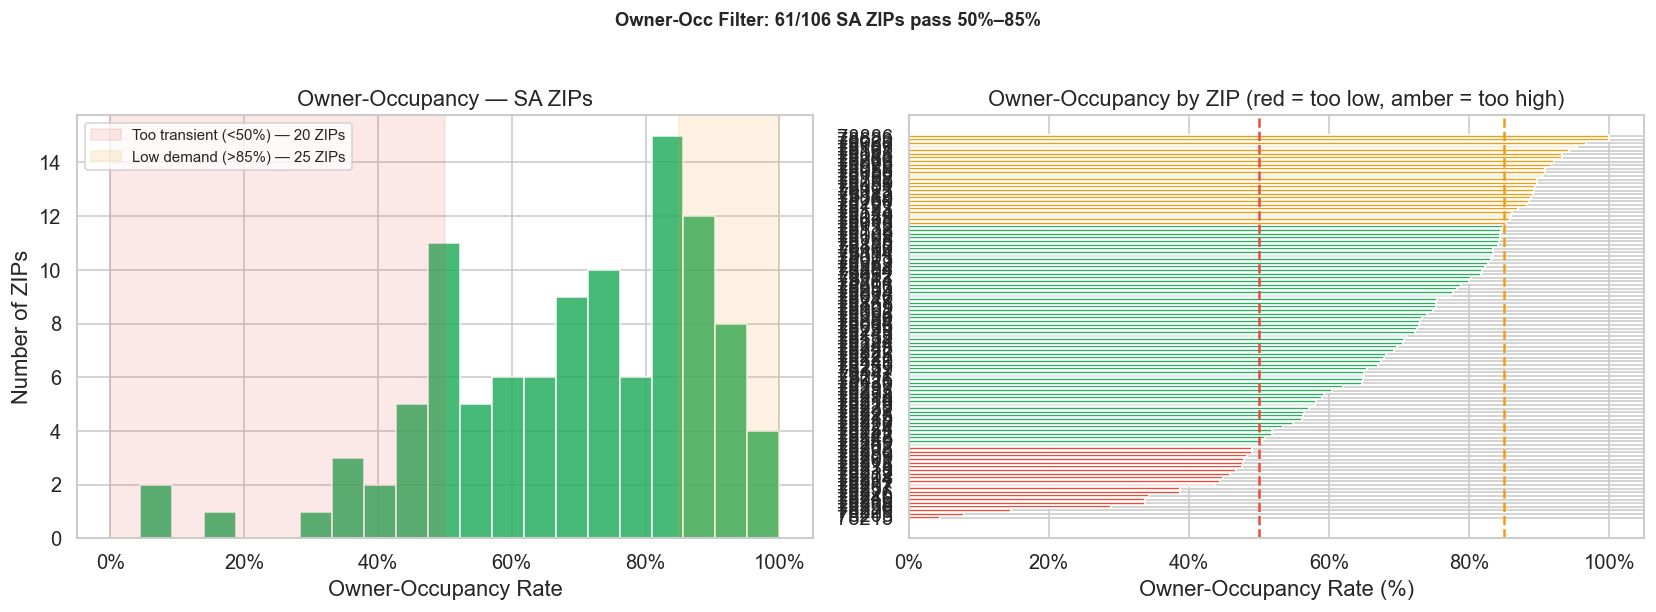

In [11]:
# 3.1 Owner-occupancy distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
min_occ = THRESHOLDS['min_owner_occ_pct']
max_occ = THRESHOLDS['max_owner_occ_pct']
n_low  = (census_sa['owner_occ_pct'] < min_occ).sum()
n_high = (census_sa['owner_occ_pct'] > max_occ).sum()
n_pass_occ = census_sa['owner_occ_pct'].between(min_occ, max_occ).sum()

ax = axes[0]
ax.hist(census_sa['owner_occ_pct'] * 100, bins=20, color=PASS_COLOR, edgecolor='white', alpha=0.85)
ax.axvspan(0,            min_occ * 100, alpha=0.12, color=FAIL_COLOR, label=f'Too transient (<{min_occ:.0%}) — {n_low} ZIPs')
ax.axvspan(max_occ * 100, 100,          alpha=0.12, color=WARN_COLOR, label=f'Low demand (>{max_occ:.0%}) — {n_high} ZIPs')
ax.set_xlabel('Owner-Occupancy Rate')
ax.set_ylabel('Number of ZIPs')
ax.set_title('Owner-Occupancy — SA ZIPs')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=9)

ax2 = axes[1]
sorted_occ = census_sa.sort_values('owner_occ_pct')
occ_colors = [FAIL_COLOR if v < min_occ else WARN_COLOR if v > max_occ else PASS_COLOR
              for v in sorted_occ['owner_occ_pct']]
ax2.barh(sorted_occ['zip'], sorted_occ['owner_occ_pct'] * 100, color=occ_colors, edgecolor='white')
ax2.axvline(min_occ * 100, color=FAIL_COLOR, linewidth=1.5, linestyle='--')
ax2.axvline(max_occ * 100, color=WARN_COLOR, linewidth=1.5, linestyle='--')
ax2.set_xlabel('Owner-Occupancy Rate (%)')
ax2.set_title('Owner-Occupancy by ZIP (red = too low, amber = too high)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.suptitle(f'Owner-Occ Filter: {n_pass_occ}/{len(census_sa)} SA ZIPs pass {min_occ:.0%}–{max_occ:.0%}',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

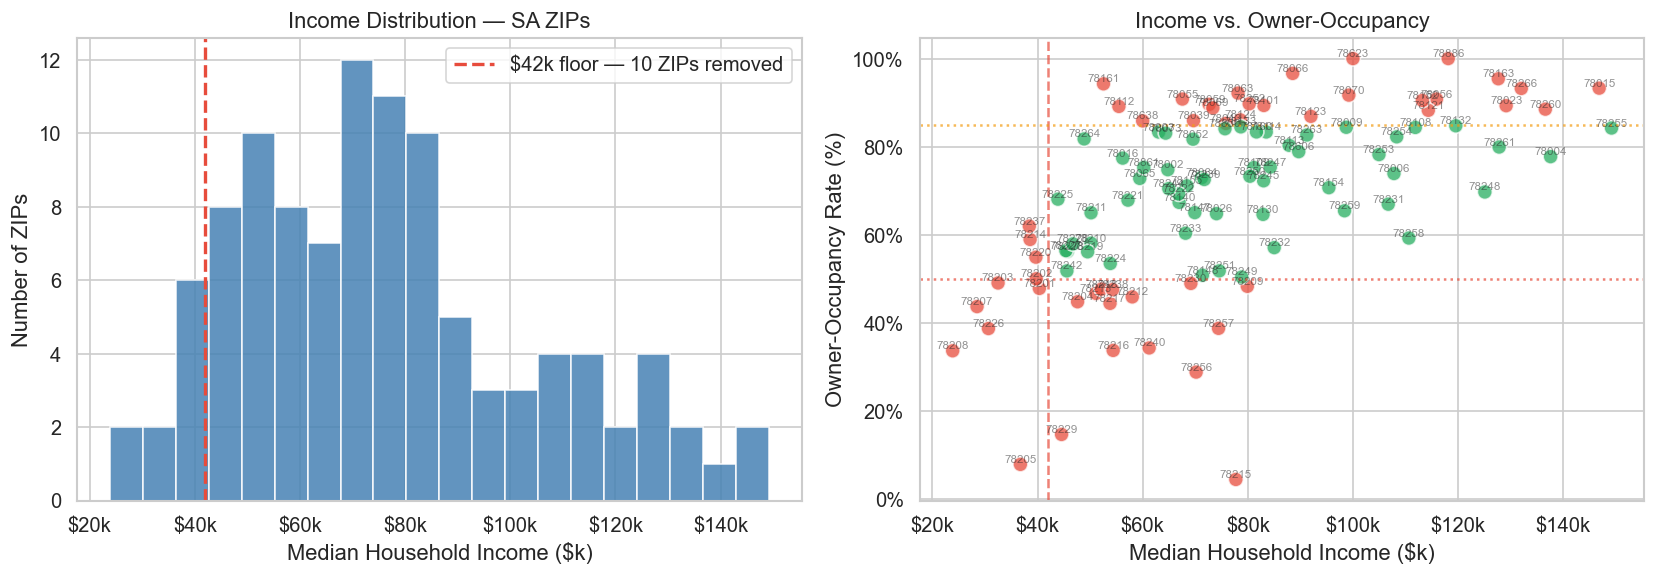

ZIPs cut by income filter only (4 total):
  zip  median_hh_income  owner_occ_pct
78237           38447.0       0.619620
78214           38591.0       0.589330
78220           39694.0       0.549075
78202           39759.0       0.500114


In [12]:
# 3.2 Income distribution and income vs owner-occ relationship
income_floor  = THRESHOLDS['min_median_income']
census_income = census_sa.dropna(subset=['median_hh_income'])
n_pass_inc = (census_income['median_hh_income'] >= income_floor).sum()
n_fail_inc = (census_income['median_hh_income'] <  income_floor).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(census_income['median_hh_income'] / 1e3, bins=20,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(income_floor / 1e3, color=FAIL_COLOR, linewidth=2, linestyle='--',
           label=f'${income_floor/1e3:.0f}k floor — {n_fail_inc} ZIPs removed')
ax.set_xlabel('Median Household Income ($k)')
ax.set_ylabel('Number of ZIPs')
ax.set_title('Income Distribution — SA ZIPs')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend()

ax2 = axes[1]
pt_colors = [
    FAIL_COLOR if (pd.notna(inc) and inc < income_floor) or occ < min_occ or occ > max_occ
    else PASS_COLOR
    for inc, occ in zip(census_sa['median_hh_income'], census_sa['owner_occ_pct'])
]
ax2.scatter(census_sa['median_hh_income'] / 1e3, census_sa['owner_occ_pct'] * 100,
            c=pt_colors, alpha=0.75, edgecolors='white', s=80)
for _, row in census_sa.iterrows():
    if pd.notna(row['median_hh_income']):
        ax2.annotate(row['zip'], (row['median_hh_income']/1e3, row['owner_occ_pct']*100),
                     fontsize=7, alpha=0.5, ha='center', va='bottom')
ax2.axvline(income_floor / 1e3, color=FAIL_COLOR, linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axhline(min_occ * 100, color=FAIL_COLOR, linestyle=':', linewidth=1.5, alpha=0.7)
ax2.axhline(max_occ * 100, color=WARN_COLOR, linestyle=':', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Median Household Income ($k)')
ax2.set_ylabel('Owner-Occupancy Rate (%)')
ax2.set_title('Income vs. Owner-Occupancy')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

# ZIPs cut ONLY by income — would pass owner-occ filter otherwise
income_only_cut = census_sa[
    census_sa['median_hh_income'].notna() &
    (census_sa['median_hh_income'] < income_floor) &
    (census_sa['owner_occ_pct'].between(min_occ, max_occ))
].sort_values('median_hh_income')
print(f"ZIPs cut by income filter only ({len(income_only_cut)} total):")
if len(income_only_cut) > 0:
    print(income_only_cut[['zip','median_hh_income','owner_occ_pct']].to_string(index=False))

**What to look for:** ZIPs cut *only* by income (bottom table) are worth examining by name. If you recognize any as legitimate house-hack targets, the $45k floor may be set too tightly. If they're all areas you'd immediately avoid, the filter is working as intended. The scatter plot should show a positive correlation between income and owner-occupancy — ZIPs that break that pattern are worth a second look.

---
## 4. SAPD Calls for Service (Crime)

**Source:** `sa_crime_raw.csv` — 5.3M SAPD dispatch records.

This is the most impactful and most uncertain data source. The model filters 5.3M rows to ~191k criminal incidents using a Problem-type allowlist. Everything downstream depends on that filter being correct.

**Questions:**
- What does the full Problem type distribution look like? Is 3.6% criminal rate plausible?
- Are there types in the allowlist that seem too minor? Types not in it that should be?
- What happens to the crime-per-1k distribution before vs. after filtering?
- Are there temporal artifacts that suggest data quality issues?

> ⚠️ **Performance note:** 600MB, 5.3M rows. Cells below use column subsetting. Expect 30–60s for the load cell.

Loading crime data (uses .cache/ — fast after first run)...


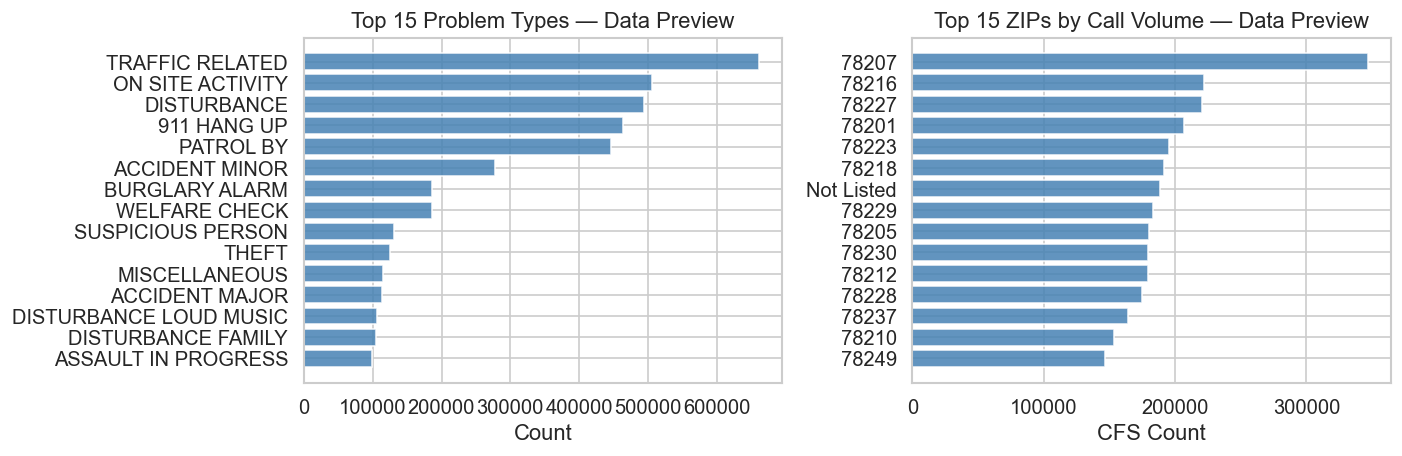

Total rows: 5,741,294
Unique ZIPs: 78
Unique Problem types: 156
Date range: 2023-01-01 00:00:12.000 to 2026-04-30 23:59:47.000


In [16]:
CRIME_COLS = ['Priority', 'Problem', 'Postal_Code', 'Response_Date', 'Weekday']
print('Loading crime data (uses .cache/ — fast after first run)...')

crime_raw = load_crime_data()
crime_raw = crime_raw[[c for c in CRIME_COLS if c in crime_raw.columns]]
crime_raw['Postal_Code'] = crime_raw['Postal_Code'].str.strip().str.zfill(5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Problem type distribution (top 15)
problem_preview = crime_raw['Problem'].str.upper().str.strip().value_counts().head(15)
axes[0].barh(problem_preview.index[::-1], problem_preview.values[::-1],
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Count')
axes[0].set_title('Top 15 Problem Types — Data Preview')

# Postal code coverage
zip_counts = crime_raw['Postal_Code'].value_counts().head(15)
axes[1].barh(zip_counts.index[::-1], zip_counts.values[::-1],
             color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('CFS Count')
axes[1].set_title('Top 15 ZIPs by Call Volume — Data Preview')

plt.tight_layout()
plt.show()

print(f'Total rows: {len(crime_raw):,}')
print(f'Unique ZIPs: {crime_raw["Postal_Code"].nunique()}')
print(f'Unique Problem types: {crime_raw["Problem"].nunique()}')
print(f'Date range: {crime_raw["Response_Date"].min()} to {crime_raw["Response_Date"].max()}')

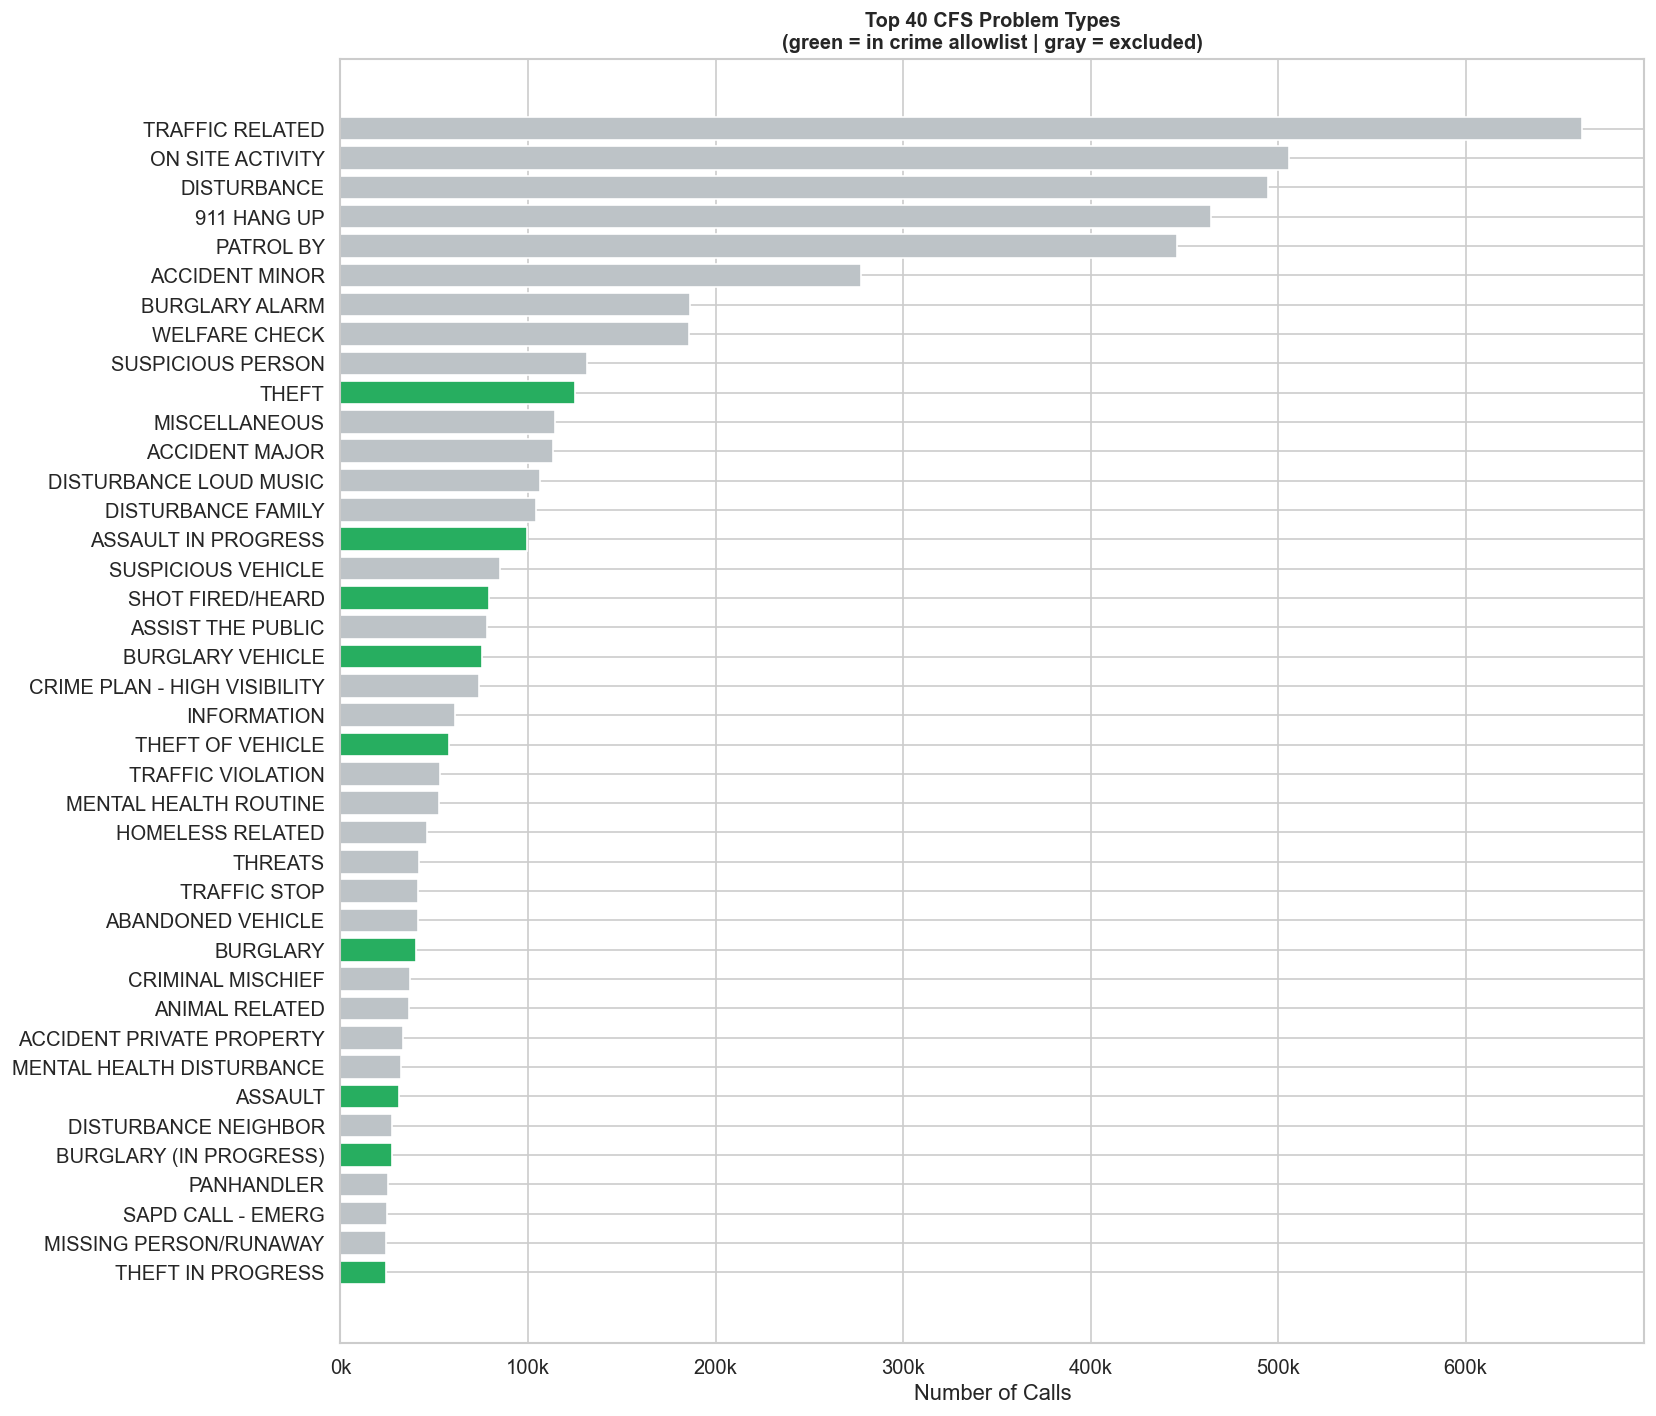

In allowlist:     750,394 calls (13.1%)
Not in list:    4,990,900 calls (86.9%)

✓ All allowlist types found in data.


In [ ]:
# 4.1 Problem type distribution — the single most important chart in this notebook
# Green = in allowlist (counted as crime), gray = excluded
problem_counts  = crime_raw['Problem'].str.upper().str.strip().value_counts()
top_40          = problem_counts.head(40)
allowlist_upper = {p.upper() for p in VIOLENT_CRIME_PROBLEMS}
colors_prob     = [PASS_COLOR if p in allowlist_upper else '#bdc3c7' for p in top_40.index]

fig, ax = plt.subplots(figsize=(14, 12))
ax.barh(top_40.index[::-1], top_40.values[::-1], color=colors_prob[::-1], edgecolor='white')
ax.set_xlabel('Number of Calls')
ax.set_title('Top 40 CFS Problem Types\n(green = in crime allowlist | gray = excluded)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.show()

in_list  = problem_counts[problem_counts.index.isin(allowlist_upper)]
not_list = problem_counts[~problem_counts.index.isin(allowlist_upper)]
pct_in   = in_list.sum() / len(crime_raw) * 100

print(f"In allowlist:  {in_list.sum():>10,} calls ({pct_in:.1f}%)")
print(f"Not in list:   {not_list.sum():>10,} calls ({100-pct_in:.1f}%)")

missing_types = allowlist_upper - set(problem_counts.index)
if missing_types:
    print(f"\n⚠ Allowlist types NOT found in data (possible spelling mismatch):")
    for t in sorted(missing_types):
        print(f"  '{t}'")
else:
    print("\n✓ All allowlist types found in data.")

**What to look for:** Look carefully at the top gray bars — are they all clearly non-criminal (MEDICAL EMERGENCY, WELFARE CHECK, NOISE DISTURBANCE, TRAFFIC STOP)? If you see a large gray bar for something that sounds criminal (CRIMINAL TRESPASSING, STALKING, HARASSMENT), add it to `VIOLENT_CRIME_PROBLEMS` in `config.py`. If you see a large green bar for something minor (CRIMINAL MISCHIEF can be graffiti), consider removing it.

The "allowlist types NOT found in data" warning is important — it means your config references problem types that use different wording in the actual dataset. Fix the spelling.

Dropping 3 ZIPs with pop < 5,000: ['78205', '78208', '78215']


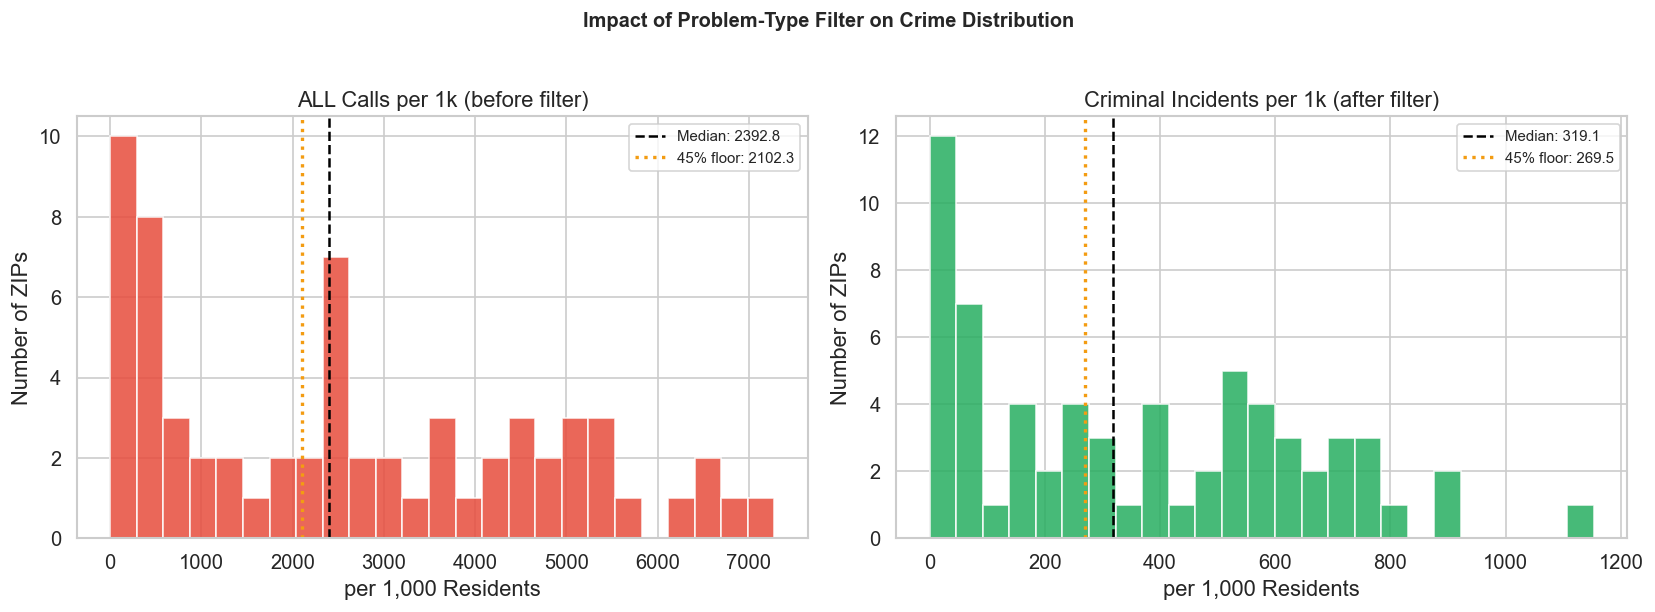

Before filter:
count      65.0
mean     2615.8
std      2136.4
min         0.0
25%       552.7
50%      2392.8
75%      4559.0
max      7279.8
Name: per_1k_all, dtype: str

After filter:
count      65.0
mean      357.2
std       293.0
min         0.0
25%        56.1
50%       319.1
75%       585.6
max      1153.2
Name: per_1k_filt, dtype: str


In [ ]:
# 4.2 Crime per-1k distribution: before vs after Problem filter
military_zips = {'78234','78235','78236','78243'}
crime_clean   = crime_raw[~crime_raw['Postal_Code'].isin(military_zips)]
census_pop    = census_valid[['zip','population']].dropna().copy()

counts_all  = crime_clean.groupby('Postal_Code').size().reset_index(name='count_all')
counts_all['zip'] = counts_all['Postal_Code']

crime_filt  = crime_clean[crime_clean['Problem'].str.upper().str.strip().isin(allowlist_upper)]
counts_filt = crime_filt.groupby('Postal_Code').size().reset_index(name='count_filt')
counts_filt['zip'] = counts_filt['Postal_Code']

crime_comp = counts_all.merge(counts_filt, on='zip', how='outer').fillna(0)
crime_comp = crime_comp.merge(census_pop, on='zip', how='left')
crime_comp = crime_comp[crime_comp['population'] > 0].copy()
thin = crime_comp["population"] < MIN_POPULATION_FOR_CRIME
if thin.sum() > 0:
    print(f"Dropping {thin.sum()} ZIPs with pop < {MIN_POPULATION_FOR_CRIME:,}: "
          f"{sorted(crime_comp.loc[thin, 'zip'].tolist())}")
    crime_comp = crime_comp[~thin].copy()
crime_comp['per_1k_all']  = crime_comp['count_all']  / crime_comp['population'] * 1000
crime_comp['per_1k_filt'] = crime_comp['count_filt'] / crime_comp['population'] * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, color in [
    (axes[0], 'per_1k_all',  'ALL Calls per 1k (before filter)',           FAIL_COLOR),
    (axes[1], 'per_1k_filt', 'Criminal Incidents per 1k (after filter)',    PASS_COLOR),
]:
    data         = crime_comp[col].dropna()
    pct_cutoff   = data.quantile(CRIME_PERCENTILE_CUTOFF)
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linewidth=1.5, linestyle='--',
               label=f'Median: {data.median():.1f}')
    ax.axvline(pct_cutoff, color=WARN_COLOR, linewidth=2, linestyle=':',
               label=f'{CRIME_PERCENTILE_CUTOFF:.0%} floor: {pct_cutoff:.1f}')
    ax.set_xlabel('per 1,000 Residents')
    ax.set_ylabel('Number of ZIPs')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Impact of Problem-Type Filter on Crime Distribution', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Before filter:")
print(crime_comp['per_1k_all'].describe().apply(lambda x: f'{x:.1f}'))
print("\nAfter filter:")
print(crime_comp['per_1k_filt'].describe().apply(lambda x: f'{x:.1f}'))

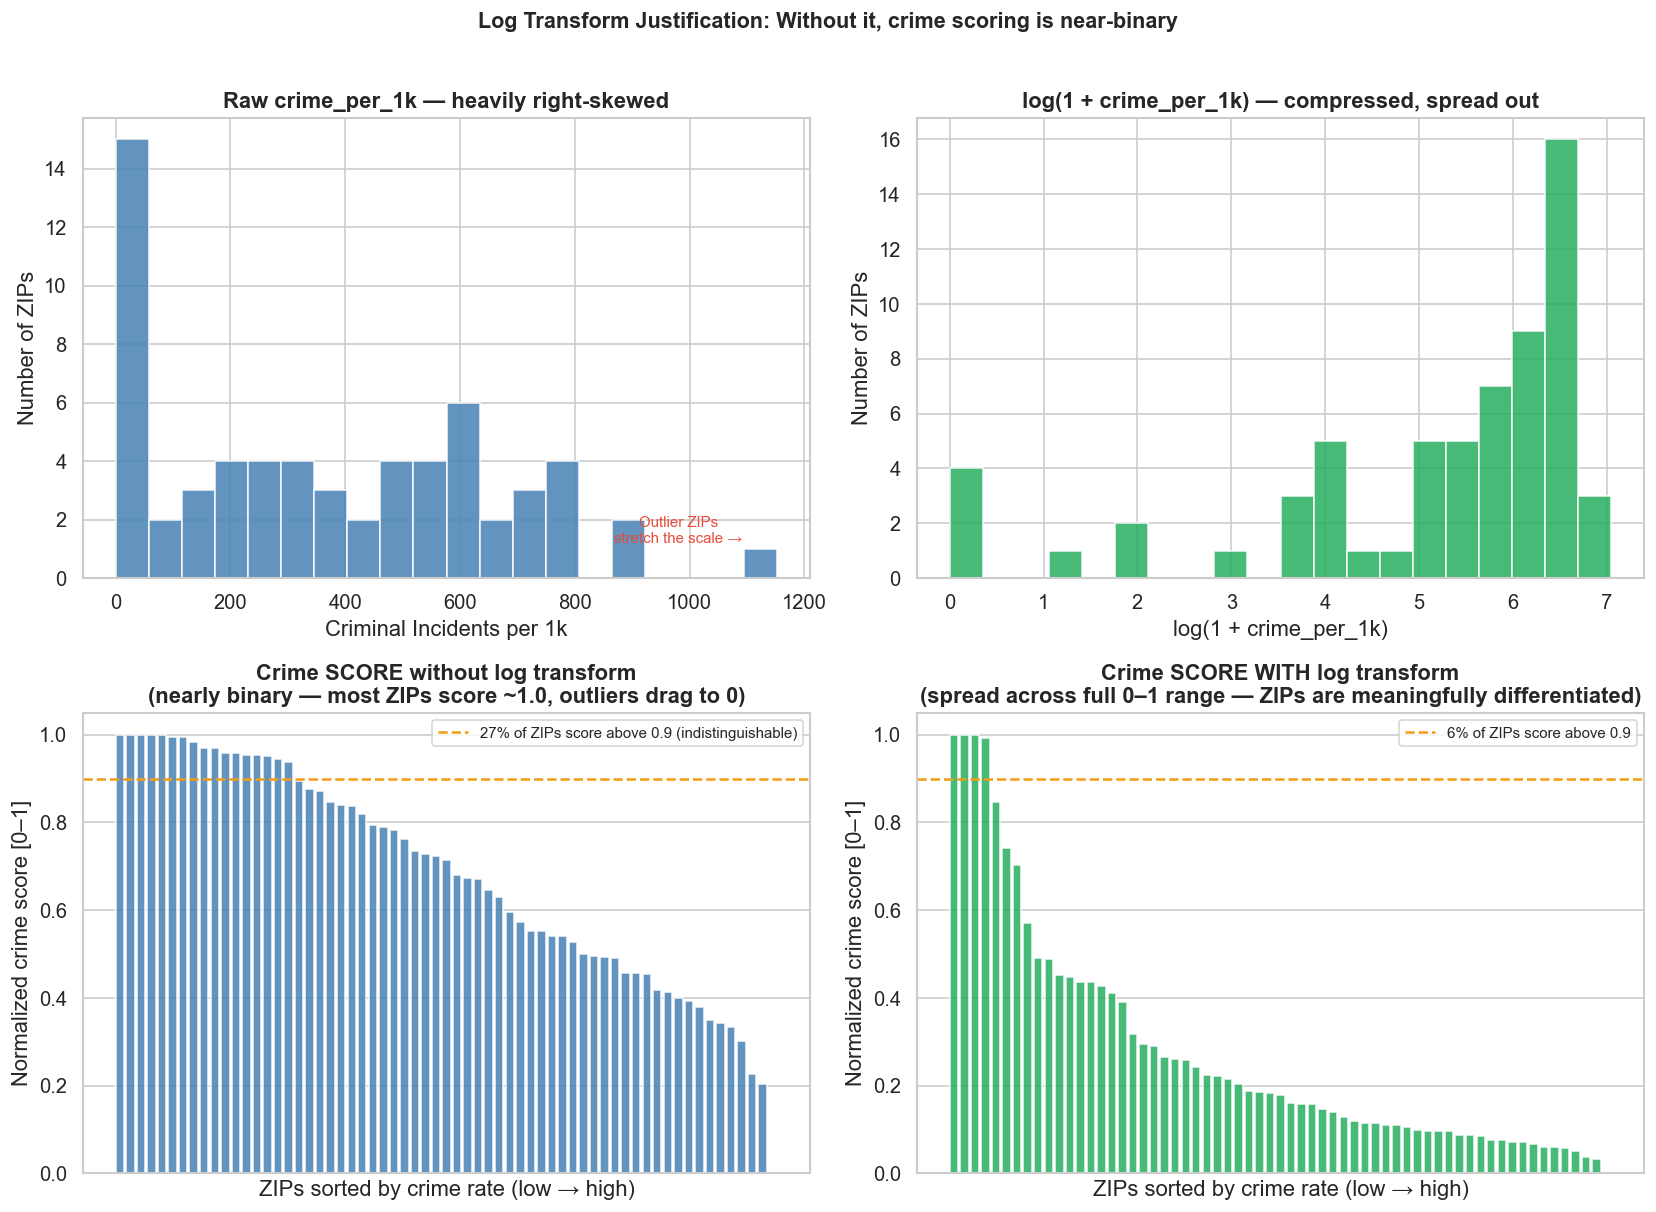

Score spread comparison (higher std = more discriminating):
  Without log: std=0.2519  IQR=0.4505
  With log:    std=0.2633  IQR=0.3055

Concrete example — how two ZIPs score under each method:
ZIP        crime/1k   score (raw)   score (log)
------------------------------------------------
0               0.0         1.000         1.000
6               0.0         1.000         1.000
8               0.0         1.000         1.000
1               0.0         1.000         0.994
63              1.9         0.998         0.847
64              5.1         0.996         0.743
7               7.2         0.994         0.702
62             19.6         0.983         0.571
55             35.3         0.969         0.490
65             35.7         0.969         0.489
4              46.9         0.959         0.451
5              48.6         0.958         0.446
2              52.1         0.955         0.437
57             52.5         0.955         0.436
43             56.1         0.951    

In [ ]:
# 4.3 Why log-transform crime? Visual justification
# The model scores crime on log(1 + crime_per_1k) instead of the raw value.
# This cell shows what happens to scoring WITHOUT the transform,
# and why it collapses all meaningful variation into a near-binary outcome.

sa_crime_raw_vals = crime_comp[crime_comp['zip'].isin(sa_zips)]['per_1k_filt'].dropna()
sa_crime_log_vals = np.log1p(sa_crime_raw_vals)

# Simulate min-max normalization — exactly what the scorer does
def minmax_invert(s):
    return 1 - (s - s.min()) / (s.max() - s.min())

score_raw = minmax_invert(sa_crime_raw_vals)
score_log = minmax_invert(sa_crime_log_vals)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Row 1: Distributions ──────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(sa_crime_raw_vals, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Raw crime_per_1k — heavily right-skewed', fontweight='bold')
ax.set_xlabel('Criminal Incidents per 1k')
ax.set_ylabel('Number of ZIPs')
# Annotate the long tail problem
ax.annotate(
    'Outlier ZIPs\nstretch the scale →',
    xy=(sa_crime_raw_vals.max() * 0.85, 1.2),
    fontsize=9, color=FAIL_COLOR, ha='center'
)

ax2 = axes[0, 1]
ax2.hist(sa_crime_log_vals, bins=20, color=PASS_COLOR, edgecolor='white', alpha=0.85)
ax2.set_title('log(1 + crime_per_1k) — compressed, spread out', fontweight='bold')
ax2.set_xlabel('log(1 + crime_per_1k)')
ax2.set_ylabel('Number of ZIPs')

# ── Row 2: What the scorer actually sees ──────────────────────────────────
# Sort ZIPs by raw crime for consistent x-axis
sorted_idx  = sa_crime_raw_vals.sort_values().index
x_pos       = range(len(sorted_idx))
zip_labels  = sa_crime_raw_vals.loc[sorted_idx].index

ax3 = axes[1, 0]
ax3.bar(x_pos, score_raw.loc[sorted_idx], color='steelblue', edgecolor='white', alpha=0.85)
ax3.set_title('Crime SCORE without log transform\n(nearly binary — most ZIPs score ~1.0, outliers drag to 0)', fontweight='bold')
ax3.set_xlabel('ZIPs sorted by crime rate (low → high)')
ax3.set_ylabel('Normalized crime score [0–1]')
ax3.set_ylim(0, 1.05)
ax3.set_xticks([])
# Show how many ZIPs are crammed near score=1.0
pct_near_top = (score_raw > 0.9).sum() / len(score_raw) * 100
ax3.axhline(0.9, color=WARN_COLOR, linestyle='--', linewidth=1.5,
            label=f'{pct_near_top:.0f}% of ZIPs score above 0.9 (indistinguishable)')
ax3.legend(fontsize=9)

ax4 = axes[1, 1]
ax4.bar(x_pos, score_log.loc[sorted_idx], color=PASS_COLOR, edgecolor='white', alpha=0.85)
ax4.set_title('Crime SCORE WITH log transform\n(spread across full 0–1 range — ZIPs are meaningfully differentiated)', fontweight='bold')
ax4.set_xlabel('ZIPs sorted by crime rate (low → high)')
ax4.set_ylabel('Normalized crime score [0–1]')
ax4.set_ylim(0, 1.05)
ax4.set_xticks([])
pct_near_top_log = (score_log > 0.9).sum() / len(score_log) * 100
ax4.axhline(0.9, color=WARN_COLOR, linestyle='--', linewidth=1.5,
            label=f'{pct_near_top_log:.0f}% of ZIPs score above 0.9')
ax4.legend(fontsize=9)

plt.suptitle(
    'Log Transform Justification: Without it, crime scoring is near-binary',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# Numerical summary: score spread
print('Score spread comparison (higher std = more discriminating):')
print(f'  Without log: std={score_raw.std():.4f}  IQR={score_raw.quantile(0.75)-score_raw.quantile(0.25):.4f}')
print(f'  With log:    std={score_log.std():.4f}  IQR={score_log.quantile(0.75)-score_log.quantile(0.25):.4f}')

# Concrete example: show how two specific ZIPs compare under each approach
print('\nConcrete example — how two ZIPs score under each method:')
print(f'{"ZIP":<8} {"crime/1k":>10} {"score (raw)":>13} {"score (log)":>13}')
print('-' * 48)
for z in sa_crime_raw_vals.sort_values().index:
    raw = sa_crime_raw_vals[z]
    print(f'{z:<8} {raw:>10.1f} {score_raw[z]:>13.3f} {score_log[z]:>13.3f}')

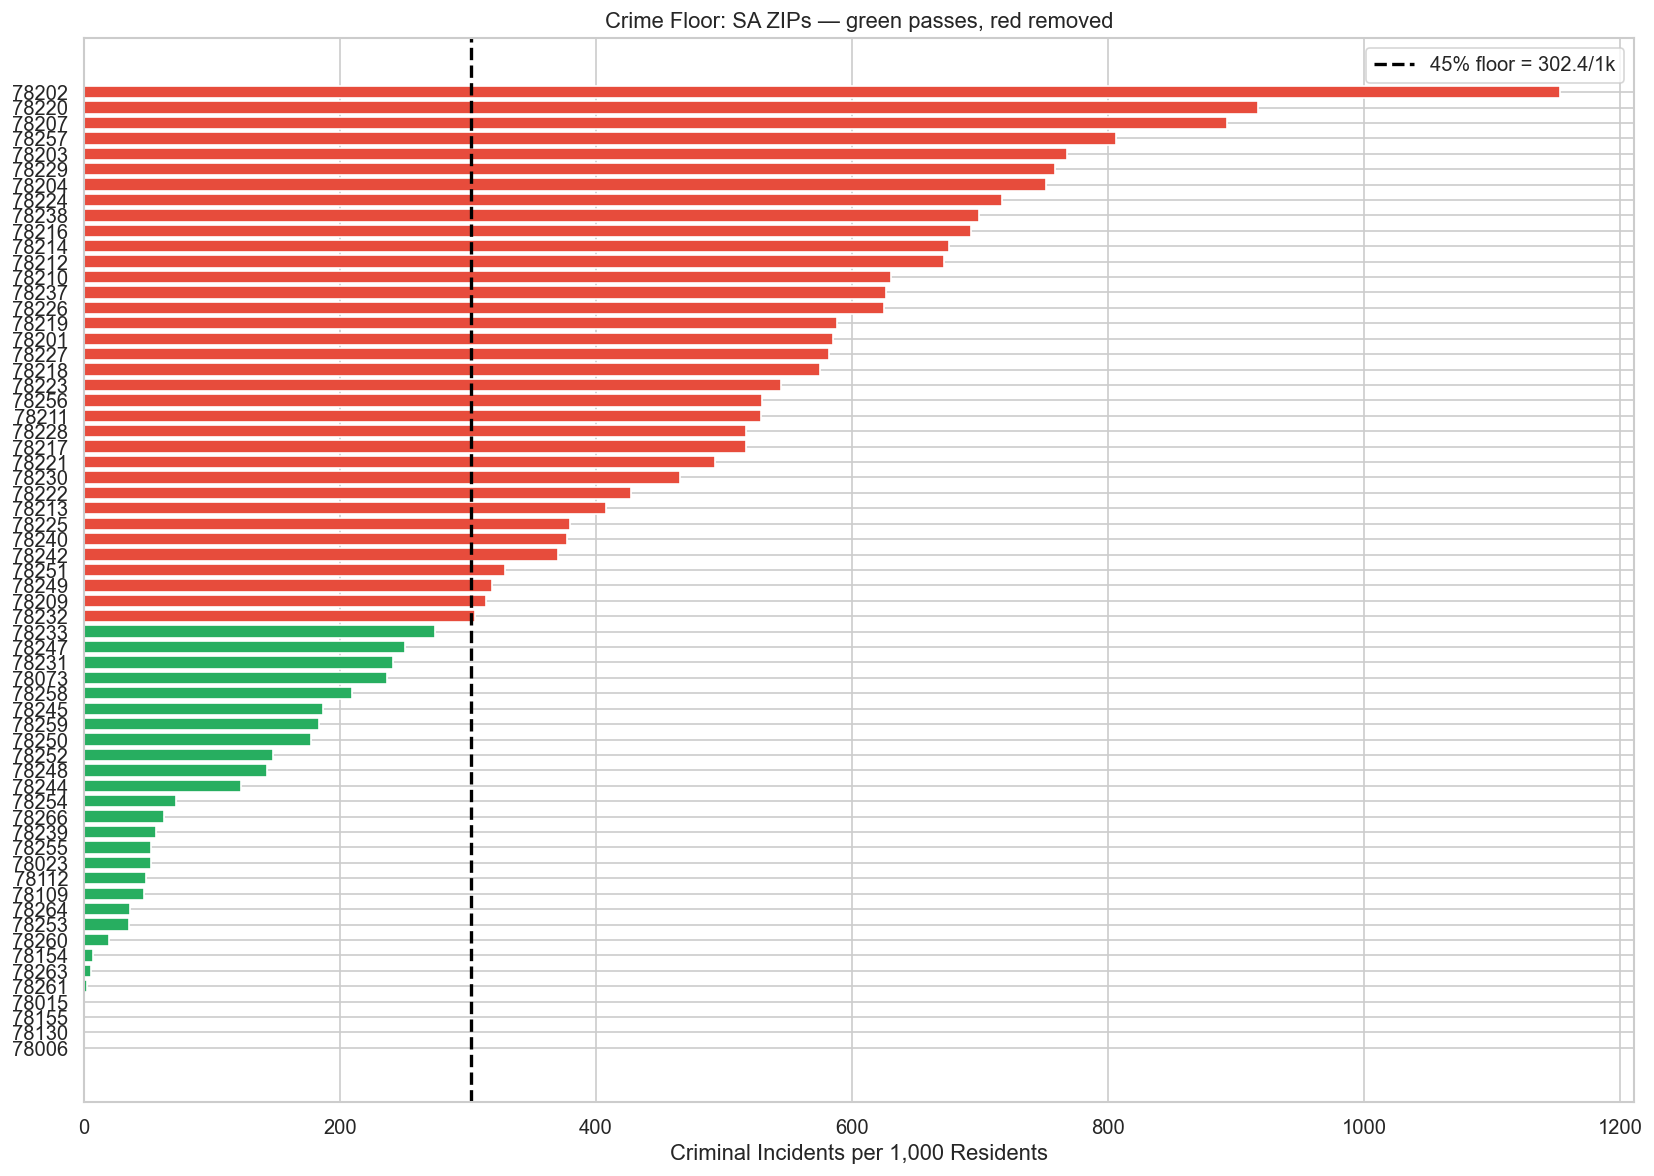

Crime floor threshold: 302.42 per 1k
SA ZIPs passing: 28 of 63


In [ ]:
# 4.3 Crime floor — which SA ZIPs survive the 50th percentile cut?
sa_crime    = crime_comp[crime_comp['zip'].isin(sa_zips)].copy()
crime_floor = sa_crime['per_1k_filt'].quantile(CRIME_PERCENTILE_CUTOFF)

sorted_crime = sa_crime.sort_values('per_1k_filt')
bar_col_c    = [PASS_COLOR if v <= crime_floor else FAIL_COLOR
                for v in sorted_crime['per_1k_filt']]

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(sorted_crime['zip'], sorted_crime['per_1k_filt'], color=bar_col_c, edgecolor='white')
ax.axvline(crime_floor, color='black', linewidth=2, linestyle='--',
           label=f'{CRIME_PERCENTILE_CUTOFF:.0%} floor = {crime_floor:.1f}/1k')
ax.set_xlabel('Criminal Incidents per 1,000 Residents')
ax.set_title(f'Crime Floor: SA ZIPs — green passes, red removed')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Crime floor threshold: {crime_floor:.2f} per 1k")
print(f"SA ZIPs passing: {(sa_crime['per_1k_filt'] <= crime_floor).sum()} of {len(sa_crime)}")

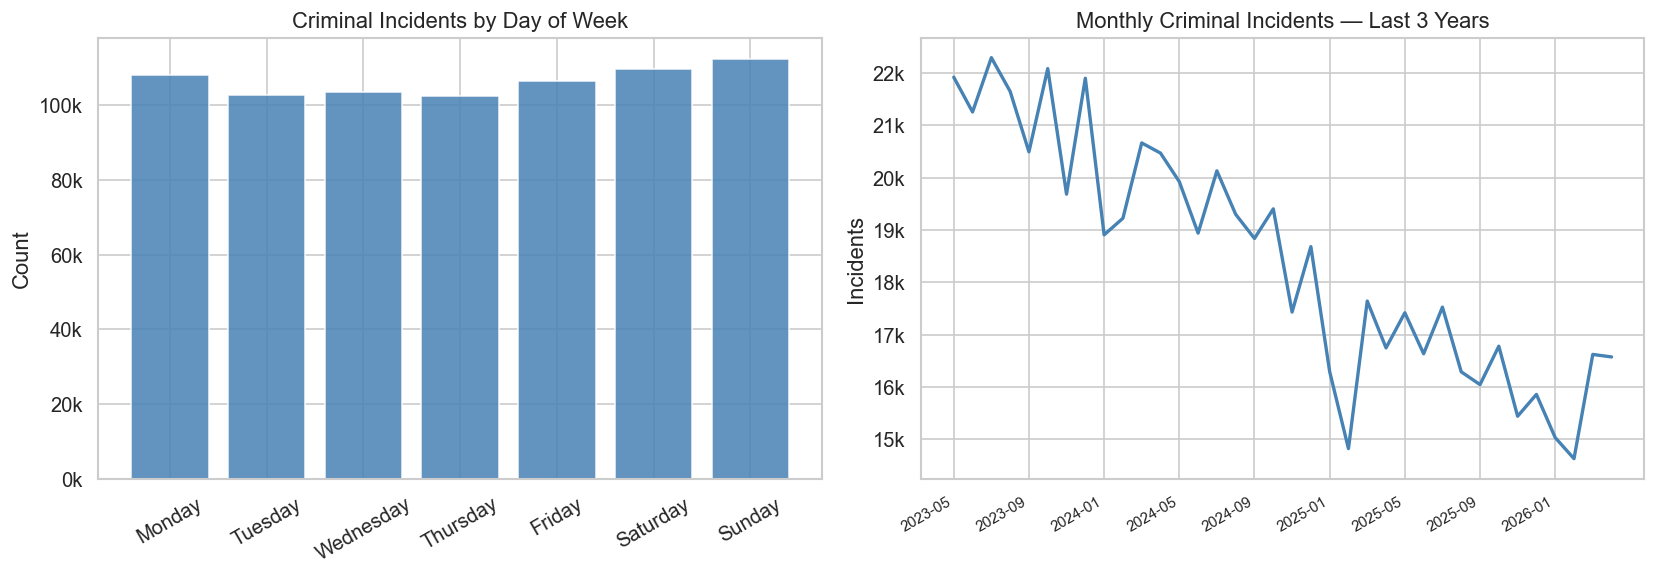

Tip: A sharp drop in the most recent months = incomplete data. That month's crime would be undercounted.


In [ ]:
# 4.4 Temporal patterns — data quality check
crime_filt_sa = crime_filt[crime_filt['Postal_Code'].isin(sa_zips)].copy()
fig, axes     = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
weekday_map = {
    'MON': 'Monday', 'TUE': 'Tuesday', 'WED': 'Wednesday', 'THU': 'Thursday',
    'FRI': 'Friday', 'SAT': 'Saturday', 'SUN': 'Sunday'
}
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

if 'Weekday' in crime_filt_sa.columns:
    weekday_clean = (
        crime_filt_sa['Weekday']
        .astype(str)
        .str.strip()
        .str.upper()
        .str[:3]
        .map(weekday_map)
    )
else:
    weekday_clean = pd.Series(index=crime_filt_sa.index, dtype='object')

# Fallback: derive weekday from Response_Date if Weekday column is missing/invalid
if weekday_clean.notna().sum() == 0 and 'Response_Date' in crime_filt_sa.columns:
    response_dt = pd.to_datetime(crime_filt_sa['Response_Date'], errors='coerce')
    weekday_clean = response_dt.dt.day_name()

day_counts = weekday_clean.value_counts().reindex(day_order, fill_value=0)
axes[0].bar(day_counts.index, day_counts.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Criminal Incidents by Day of Week')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[0].tick_params(axis='x', rotation=30)

# Monthly trend — look for sudden drops that indicate incomplete data
if 'Response_Date' in crime_filt_sa.columns:
    crime_filt_sa['Response_Date'] = pd.to_datetime(crime_filt_sa['Response_Date'], errors='coerce')
    crime_filt_sa['month'] = crime_filt_sa['Response_Date'].dt.to_period('M')
    monthly = crime_filt_sa.groupby('month').size().sort_index().tail(36)
    monthly = monthly[monthly.index.notna()]
    axes[1].plot(range(len(monthly)), monthly.values, color='steelblue', linewidth=2)
    tick_step = max(1, len(monthly) // 8)
    axes[1].set_xticks(range(0, len(monthly), tick_step))
    axes[1].set_xticklabels([str(monthly.index[i]) for i in range(0, len(monthly), tick_step)],
                             rotation=30, ha='right', fontsize=9)
    axes[1].set_title('Monthly Criminal Incidents — Last 3 Years')
    axes[1].set_ylabel('Incidents')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.tight_layout()
plt.show()
print("Tip: A sharp drop in the most recent months = incomplete data. That month's crime would be undercounted.")

---
## 5. Cross-Source: ZIP Overlap & Filter Funnel

The model inner-joins all five data sources — a ZIP must appear in all of them to be scored. Understanding where ZIPs drop out shows whether gaps are random or systematic.

**The filter funnel** tracks how many ZIPs survive each stage, from raw data through every filter to the final scored pool.

In [ ]:
# 5.1 ZIP overlap by source
sets = {
    'ZHVI':      set(zhvi_sa['zip']),
    'ZORI':      set(zori_sa['zip']),
    'Census':    set(census_sa['zip']),
    'Crime':     set(sa_crime['zip']),
    'Stability': set(zhvi_sa[zhvi_sa['cov'].notna()]['zip']),
}

print("ZIP coverage by source (overlap with ZHVI):")
for name, s in sets.items():
    overlap = len(s & sets['ZHVI'])
    print(f"  {name:<12}: {len(s):>4} total | {overlap:>4} in ZHVI")

print("\nZIPs in ZHVI with no ZORI rent data:")
print(sorted(sets['ZHVI'] - sets['ZORI']))

print("\nZIPs in ZHVI with no crime data:")
print(sorted(sets['ZHVI'] - sets['Crime']))

ZIP coverage by source (overlap with ZHVI):
  ZHVI        :  106 total |  106 in ZHVI
  ZORI        :   70 total |   69 in ZHVI
  Census      :  106 total |  106 in ZHVI
  Crime       :   63 total |   63 in ZHVI
  Stability   :  106 total |  106 in ZHVI

ZIPs in ZHVI with no ZORI rent data:
['78002', '78003', '78004', '78009', '78013', '78016', '78026', '78039', '78052', '78055', '78056', '78059', '78063', '78064', '78065', '78066', '78069', '78073', '78101', '78112', '78113', '78121', '78123', '78124', '78140', '78147', '78160', '78161', '78226', '78263', '78264', '78266', '78623', '78638', '78850', '78861', '78886']

ZIPs in ZHVI with no crime data:
['78002', '78003', '78004', '78009', '78013', '78016', '78026', '78039', '78052', '78055', '78056', '78059', '78063', '78064', '78065', '78066', '78069', '78070', '78101', '78108', '78113', '78114', '78121', '78123', '78124', '78132', '78133', '78140', '78147', '78148', '78152', '78160', '78161', '78163', '78205', '78208', '78215', '78606

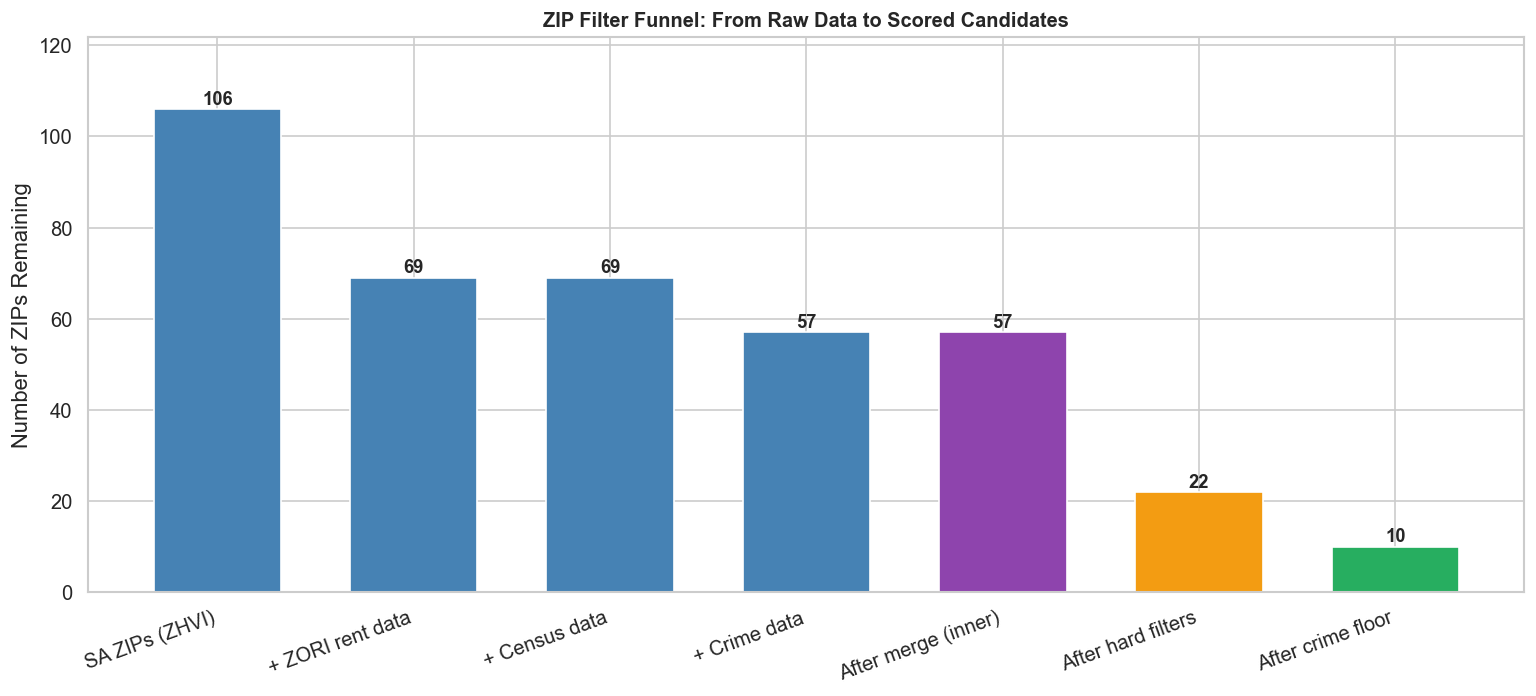


Funnel stage summary:
  SA ZIPs (ZHVI)                : 106
  + ZORI rent data              : 69
  + Census data                 : 69
  + Crime data                  : 57
  After merge (inner)           : 57
  After hard filters            : 22
  After crime floor             : 10


In [ ]:
# 5.2 Filter funnel waterfall
# Reconstruct the pipeline stages to show cumulative ZIP loss

merged_full = merged_yield.merge(
    census_sa[['zip','owner_occ_pct','median_hh_income']], on='zip', how='inner')
merged_full = merged_full.merge(
    sa_crime[['zip','per_1k_filt']].rename(columns={'per_1k_filt':'crime_per_1k'}), on='zip', how='inner')

if 'commute_minutes' not in merged_full.columns:
    # Recompute straight-line commute for the merged pool
    from utils import load_zip_centroids
    from commute import add_straight_line_distance
    coords = load_zip_centroids()
    base = merged_full[['zip']].merge(coords, on='zip', how='left')
    commute_tmp = add_straight_line_distance(base)[['zip', 'commute_minutes']]
    merged_full = merged_full.merge(commute_tmp, on='zip', how='left')

merged_full['pass_yield']  = merged_full['rent_to_price'] >= THRESHOLDS['min_rent_to_price']
merged_full['pass_price']  = merged_full['current_value'] <= THRESHOLDS['max_home_value']
merged_full['pass_occ_lo'] = merged_full['owner_occ_pct'] >= THRESHOLDS['min_owner_occ_pct']
merged_full['pass_occ_hi'] = merged_full['owner_occ_pct'] <= THRESHOLDS['max_owner_occ_pct']
merged_full['pass_income'] = (
    merged_full['median_hh_income'].isna() |
    (merged_full['median_hh_income'] >= THRESHOLDS['min_median_income'])
)
merged_full['pass_commute'] = merged_full['commute_minutes'] <= MAX_COMMUTE_MINS
all_hard = (merged_full['pass_yield'] & merged_full['pass_price'] &
            merged_full['pass_occ_lo'] & merged_full['pass_occ_hi'] &
            merged_full['pass_income'] & merged_full['pass_commute'])

crime_threshold = merged_full.loc[all_hard, 'crime_per_1k'].quantile(CRIME_PERCENTILE_CUTOFF)

stage_zori   = sets['ZHVI'] & sets['ZORI']
stage_census = stage_zori & sets['Census']
stage_crime  = stage_census & sets['Crime']
stage_merged = set(merged_full['zip'])

stages = [
    ('SA ZIPs (ZHVI)',       len(sets['ZHVI'])),
    ('+ ZORI rent data',     len(stage_zori)),
    ('+ Census data',        len(stage_census)),
    ('+ Crime data',         len(stage_crime)),
    ('After merge (inner)',  len(stage_merged)),
    ('After hard filters',   int(all_hard.sum())),
    ('After crime floor',    int((all_hard & (merged_full['crime_per_1k'] <= crime_threshold)).sum())),
]

labels = [s[0] for s in stages]
values = [s[1] for s in stages]

fig, ax = plt.subplots(figsize=(13, 6))
bar_colors = ['steelblue'] * 4 + ['#8e44ad', WARN_COLOR, PASS_COLOR]
bars = ax.bar(labels, values, color=bar_colors, edgecolor='white', width=0.65)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Number of ZIPs Remaining')
ax.set_title('ZIP Filter Funnel: From Raw Data to Scored Candidates', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print("\nFunnel stage summary:")
for label, val in stages:
    print(f"  {label:<30}: {val}")

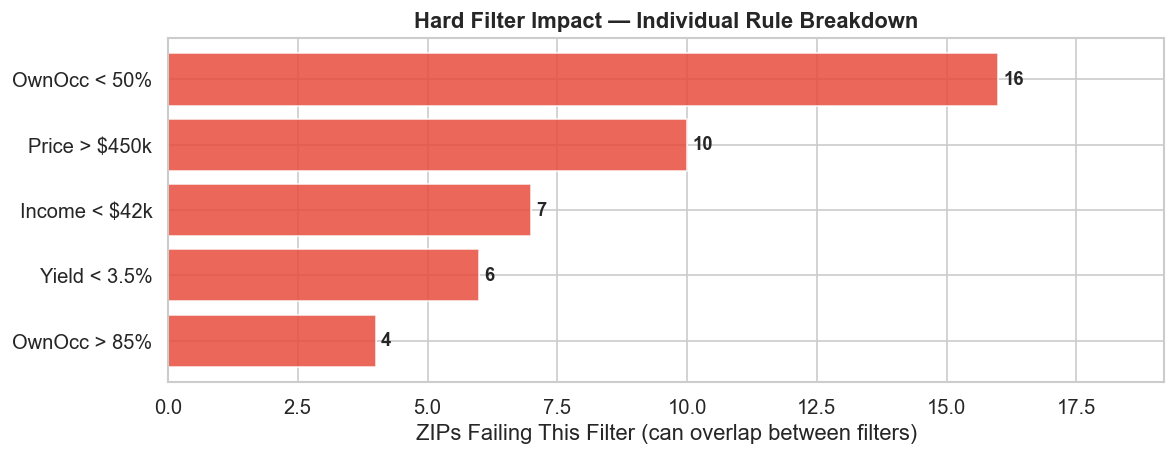

Total ZIPs removed by hard filters: 35
Surviving: 22


In [ ]:
# 5.3 Individual filter impact — which rule is most constraining?
filter_audit = {
    f'Yield < {THRESHOLDS["min_rent_to_price"]:.1%}':      (~merged_full['pass_yield']).sum(),
    f'Price > ${THRESHOLDS["max_home_value"]/1e3:.0f}k':   (~merged_full['pass_price']).sum(),
    f'OwnOcc < {THRESHOLDS["min_owner_occ_pct"]:.0%}':     (~merged_full['pass_occ_lo']).sum(),
    f'OwnOcc > {THRESHOLDS["max_owner_occ_pct"]:.0%}':     (~merged_full['pass_occ_hi']).sum(),
    f'Income < ${THRESHOLDS["min_median_income"]/1e3:.0f}k': (~merged_full['pass_income']).sum(),
}
audit_df = pd.Series(filter_audit).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(audit_df.index, audit_df.values, color=FAIL_COLOR, edgecolor='white', alpha=0.85)
for i, val in enumerate(audit_df.values):
    ax.text(val + 0.1, i, str(val), va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('ZIPs Failing This Filter (can overlap between filters)')
ax.set_title('Hard Filter Impact — Individual Rule Breakdown', fontweight='bold')
ax.set_xlim(0, audit_df.max() * 1.2)
plt.tight_layout()
plt.show()

print(f"Total ZIPs removed by hard filters: {(~all_hard).sum()}")
print(f"Surviving: {all_hard.sum()}")

Final scored pool: 10 ZIPs

                   mean         50%         min         max
Yield             0.065       0.065       0.039       0.085
Home Value   282681.473  262858.988  215763.504  401164.187
Crime/1k        174.393     180.633       7.154     319.127
Owner-Occ         0.671       0.706       0.504       0.754
Med. Income   80837.000   80777.500   64968.000   98399.000


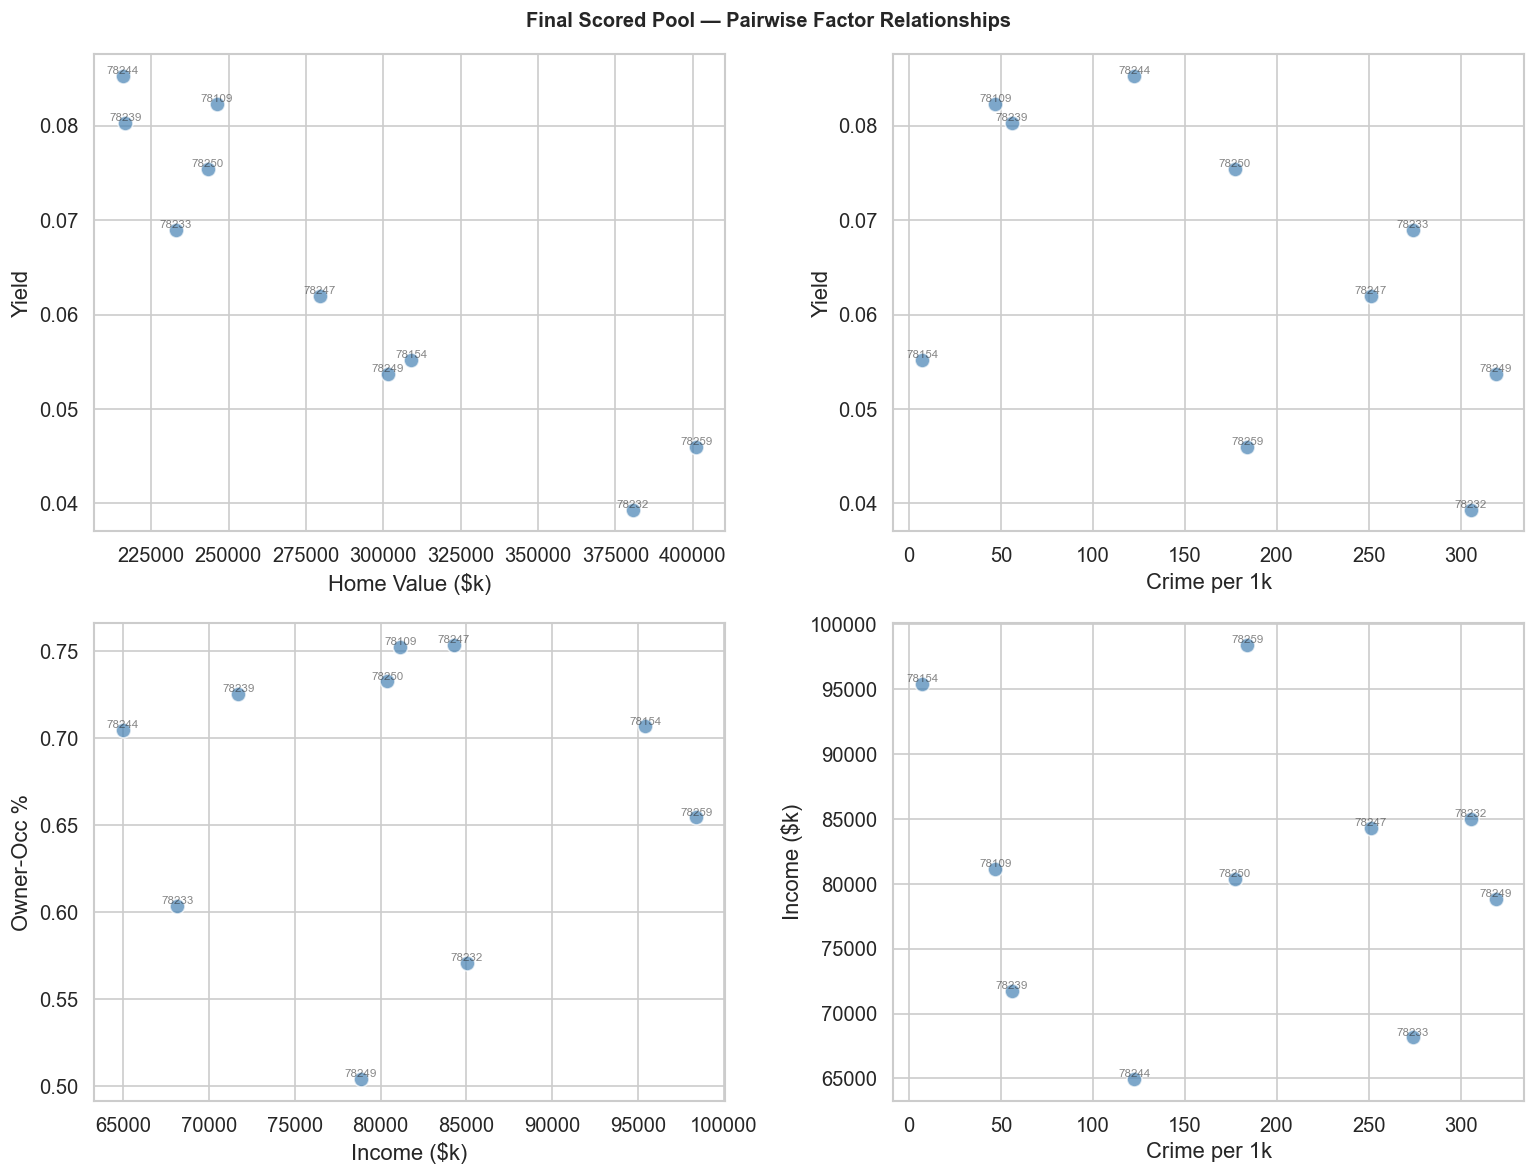

In [ ]:
# 5.4 Final pool — multi-factor profile
final_pool = merged_full[all_hard & (merged_full['crime_per_1k'] <= crime_threshold)].copy()
print(f"Final scored pool: {len(final_pool)} ZIPs\n")

profile = final_pool[['rent_to_price','current_value','crime_per_1k','owner_occ_pct','median_hh_income']].describe().T
profile.index = ['Yield','Home Value','Crime/1k','Owner-Occ','Med. Income']
print(profile[['mean','50%','min','max']].round(3).to_string())

# Pairwise scatter: final pool factors
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
pairs = [
    ('current_value',   'rent_to_price',  'Home Value ($k)', 'Yield',        axes[0,0]),
    ('crime_per_1k',    'rent_to_price',  'Crime per 1k',    'Yield',        axes[0,1]),
    ('median_hh_income','owner_occ_pct',  'Income ($k)',     'Owner-Occ %',  axes[1,0]),
    ('crime_per_1k',    'median_hh_income','Crime per 1k',   'Income ($k)',  axes[1,1]),
]
for xcol, ycol, xlabel, ylabel, ax in pairs:
    ax.scatter(final_pool[xcol], final_pool[ycol],
               color='steelblue', alpha=0.7, edgecolors='white', s=80)
    for _, row in final_pool.iterrows():
        ax.annotate(row['zip'], (row[xcol], row[ycol]),
                    fontsize=7, alpha=0.55, ha='center', va='bottom')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
plt.suptitle('Final Scored Pool — Pairwise Factor Relationships', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Findings & Config Calibration Notes

Fill this in as you run the notebook. The goal is to end with concrete actions for `config.py`.

### ZHVI
- Home value ceiling ($450k): ___ ZIPs removed. Removed ZIPs: ___
- Most stable ZIP (lowest CoV): ___ | Least stable: ___
- 3-year appreciation range: ___% to ___%
- Does CoV spread ZIPs meaningfully? ___

### ZORI / Yield
- Yield floor (7.2%): ___ ZIPs removed of ___
- Borderline ZIPs (within 15% below floor): ___
- Rent trend over last 24 months: rising / flat / falling?

### Census
- Owner-occ filter: ___ ZIPs too low, ___ too high
- Income filter: ___ ZIPs removed
- ZIPs cut only by income (review by name): ___

### Crime
- Criminal incident % of total CFS calls: ___%
- Allowlist types missing from data (spelling mismatch): ___
- Problem types to ADD to allowlist: ___
- Problem types to REMOVE from allowlist: ___
- Crime floor threshold: ___ per 1k | ___ ZIPs removed
- Temporal anomaly (incomplete recent months?): ___

### Filter Funnel
- Biggest single ZIP loss stage: ___
- Final scored pool size: ___
- Most constraining individual filter: ___

### Suggested `config.py` Changes
- [ ] `min_rent_to_price`: change to ___
- [ ] `max_home_value`: change to ___
- [ ] `min_owner_occ_pct`: change to ___
- [ ] `min_median_income`: change to ___
- [ ] `CRIME_PERCENTILE_CUTOFF`: change to ___
- [ ] Add to `VIOLENT_CRIME_PROBLEMS`: ___
- [ ] Remove from `VIOLENT_CRIME_PROBLEMS`: ___

---
## 7. Zillow Home Value Forecast (ZHVF) — Scored ZIPs

**Source:** `zhvf_growth_zip.csv` — Zillow's forward-looking ZIP-level price forecast.

**Prerequisite:** `data/final/ranked_zip_scores.csv` must exist (run `python main.py --no-google-maps` first).

**Questions:**
- Where has each scored ZIP's price been over the last 5 years? (Historical context)
- What does Zillow's forecast say for the next 12 months? (Near-term signal)
- How does the forecasted decline compare to long-term CAGR? (Is this a blip or a trend?)
- Where in the price cycle is each ZIP — still correcting from 2022 peak, or near the trough?

In [ ]:
from config import ZHVI_CAGR_WINDOWS

zhvf_raw = load_zhvf()
if zhvf_raw is None:
    raise RuntimeError('ZHVF data unavailable — Zillow fetch failed. Check network or retry later.')
zhvf_raw['RegionName'] = zhvf_raw['RegionName'].str.zfill(5)

# Load scored ZIPs — requires pipeline to have run
scored_path = ROOT / 'data' / 'final' / 'ranked_zip_scores.csv'
if not scored_path.exists():
    raise FileNotFoundError(
        f"'{scored_path}' not found. Run: python main.py --no-google-maps"
    )
scored_out = pd.read_csv(scored_path, dtype={'zip': str})
scored_out['zip'] = scored_out['zip'].str.zfill(5)
scored_out = scored_out.sort_values('rank').reset_index(drop=True)
scored_zips = scored_out['zip'].tolist()

# Filter datasets to scored ZIPs only
zhvf = zhvf_raw[zhvf_raw['RegionName'].isin(scored_zips)].rename(columns={'RegionName': 'zip'})
zhvi_scored = zhvi_sa[zhvi_sa['zip'].isin(scored_zips)].copy()

# Forecast column map: raw_col -> months_from_baseline
FORECAST_COLS = {'2026-02-28': 1, '2026-04-30': 3, '2027-01-31': 12}
BASE_DATE     = '2026-01-31'
HISTORY_YEARS = 5
N_HIST        = HISTORY_YEARS * 12
hist_cols     = date_cols[-N_HIST:]   # reuse date_cols from Section 1

# ── CAGR + forecast summary table ─────────────────────────────────────────────
print(f'Scored ZIPs: {scored_zips}')
print(f'ZHVI history window: {hist_cols[0]} → {hist_cols[-1]}  ({N_HIST} months)')
print(f'ZHVF baseline: {BASE_DATE}\n')

header = f"  {'ZIP':>5}  {'#':>3}  {'3yr CAGR':>10}  {'5yr CAGR':>10}  {'10yr CAGR':>11}  {'ZHVF 12mo':>10}  {'Below Peak':>11}"
print(header)
print(f"  {'─'*72}")

rows = []
for _, sc in scored_out.iterrows():
    z = sc['zip']
    zrow  = zhvi_scored[zhvi_scored['zip'] == z]
    zfrow = zhvf[zhvf['zip'] == z]
    if zrow.empty:
        continue
    hist_vals = pd.to_numeric(zrow[hist_cols].iloc[0], errors='coerce')
    current   = hist_vals.iloc[-1]
    peak      = hist_vals.max()
    pct_below_peak = (peak - current) / peak * 100

    cagrs = {}
    for yrs in [3, 5, 10]:
        nm = yrs * 12
        if len(date_cols) >= nm + 1:
            s = pd.to_numeric(zrow[date_cols[-(nm+1)]].iloc[0], errors='coerce')
            e = pd.to_numeric(zrow[date_cols[-1]].iloc[0],      errors='coerce')
            cagrs[yrs] = ((e / s) ** (1/yrs) - 1) * 100 if s and s > 0 else float('nan')

    zhvf_12 = float('nan')
    if not zfrow.empty and '2027-01-31' in zfrow.columns:
        zhvf_12 = pd.to_numeric(zfrow['2027-01-31'].iloc[0], errors='coerce')

    rows.append({'zip': z, 'rank': sc['rank'], 'current': current, 'peak': peak,
                 'pct_below_peak': pct_below_peak, 'zhvf_12': zhvf_12, **cagrs})

    c3 = f"{cagrs.get(3, float('nan')):>+9.1f}%"
    c5 = f"{cagrs.get(5, float('nan')):>+9.1f}%"
    c10= f"{cagrs.get(10, float('nan')):>+10.1f}%"
    zf = f"{zhvf_12:>+9.1f}%" if not pd.isna(zhvf_12) else f"{'N/A':>10}"
    bp = f"{-pct_below_peak:>+10.1f}%"
    print(f"  {z:>5}  #{sc['rank']:.0f}  {c3}  {c5}  {c10}  {zf}  {bp}")

print(f"\n  '3yr CAGR' is negative for all ZIPs — measuring from the 2022 post-COVID peak.")
print(f"  '5yr/10yr CAGR' reflects the longer structural appreciation trend.")
print(f"  'ZHVF 12mo' is cumulative % from {BASE_DATE} baseline (not annualized).")
print(f"  'Below Peak' = how far current price sits below the 5yr maximum.")

# Store for later cells
eda_rows = rows

Scored ZIPs: ['78239', '78109', '78244', '78247', '78250', '78233', '78259', '78232', '78249', '78251']
ZHVI history window: 2021-04-30 → 2026-03-31  (60 months)
ZHVF baseline: 2026-01-31

    ZIP    #    3yr CAGR    5yr CAGR    10yr CAGR   ZHVF 12mo   Below Peak
  ────────────────────────────────────────────────────────────────────────
  78239  #1       -3.1%       +2.4%        +4.9%         N/A       -11.0%
  78109  #2       -3.0%       +3.2%        +4.8%         N/A       -10.5%
  78244  #3       -3.7%       +2.8%        +5.3%         N/A       -11.9%
  78247  #4       -1.9%       +3.5%        +5.0%         N/A        -6.2%
  78250  #5       -1.9%       +3.4%        +5.2%         N/A        -7.2%
  78233  #6       -2.2%       +3.0%        +5.1%         N/A        -7.4%
  78259  #7       -1.0%       +4.6%        +4.7%         N/A        -3.5%
  78232  #8       +0.1%       +4.4%        +5.0%         N/A        -1.3%
  78249  #9       -1.7%       +3.6%        +4.9%         N/A        -

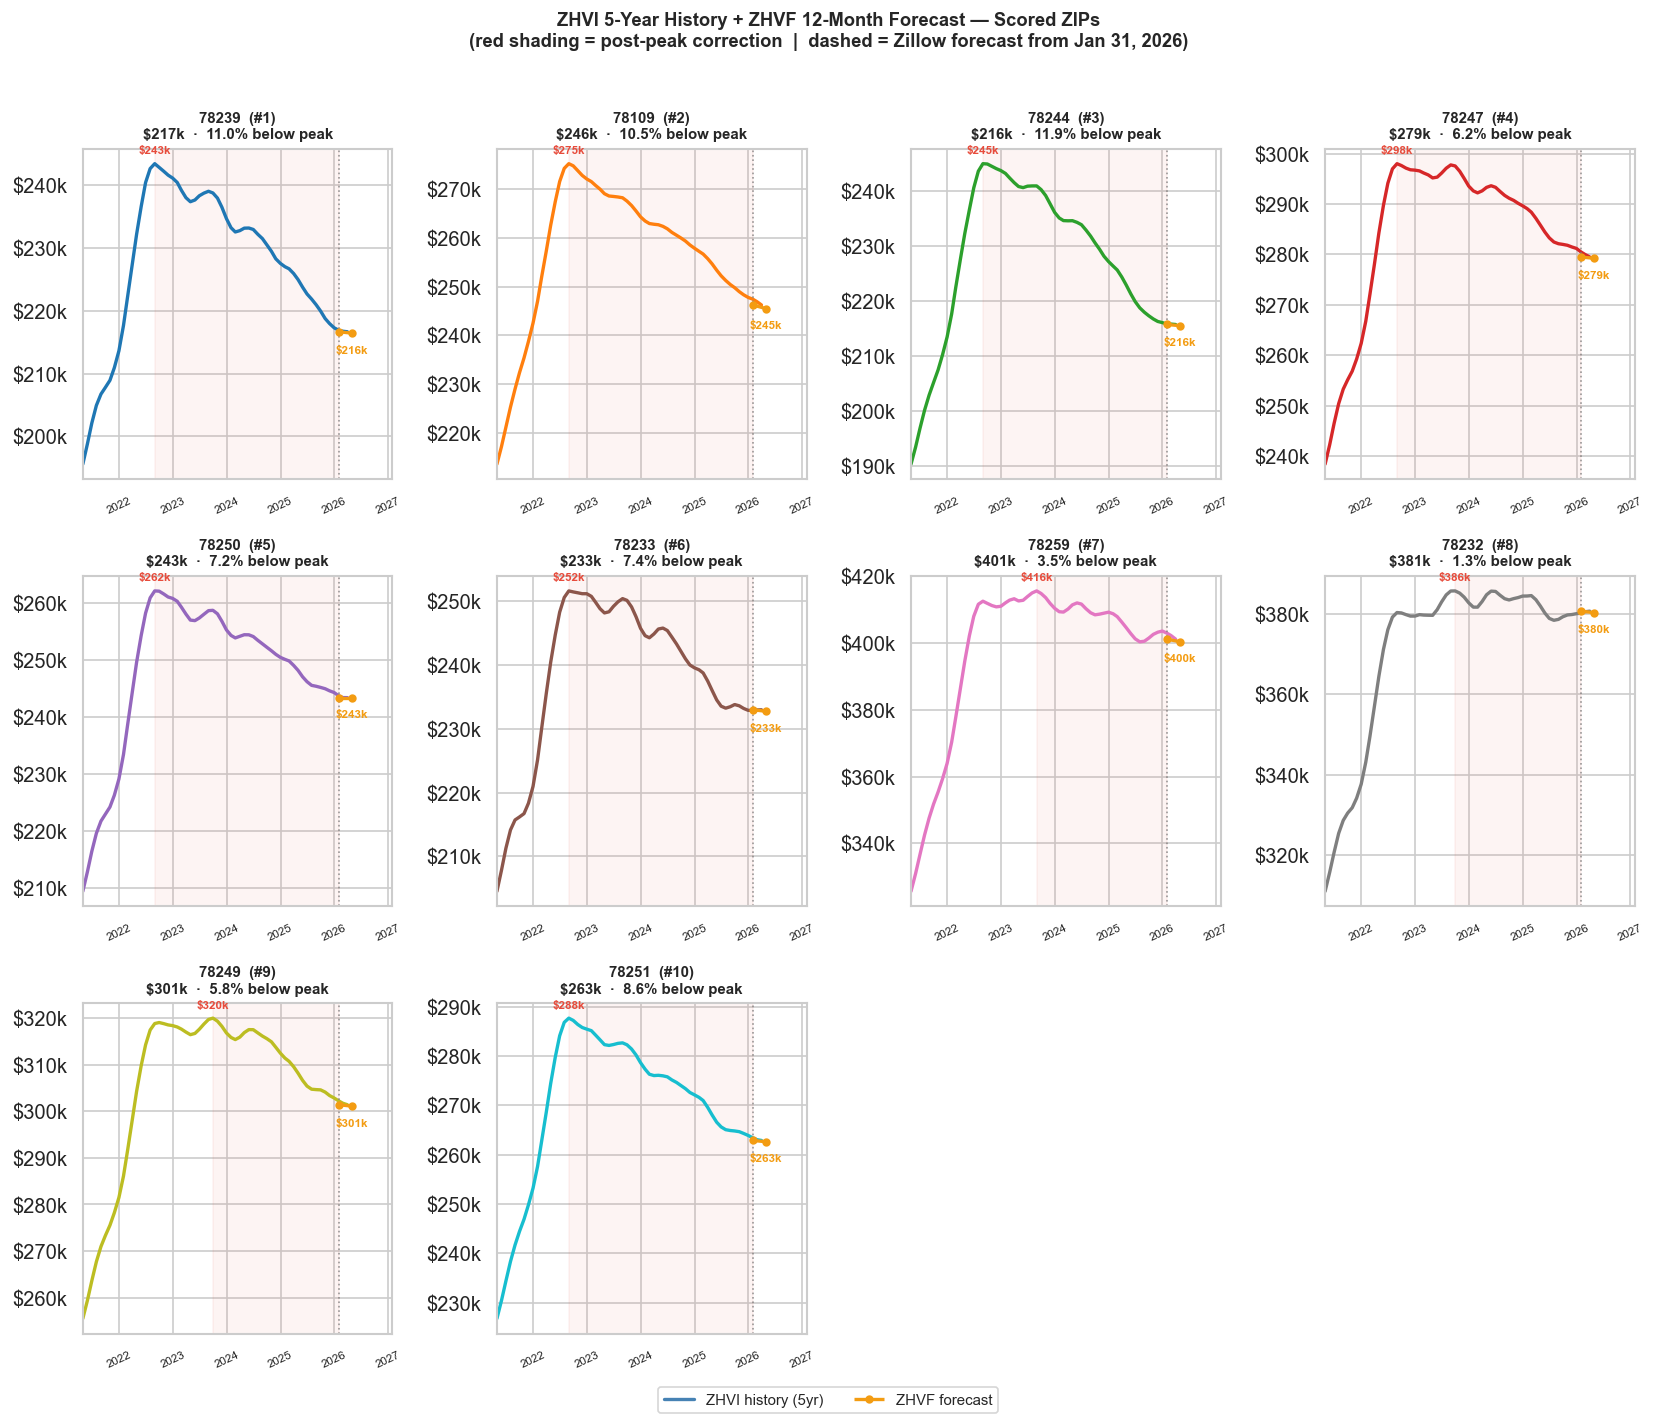

In [ ]:
# ── Per-ZIP: ZHVI 5yr history + ZHVF forecast splice ────────────────────────
# Each panel shows where a ZIP's price has been and where Zillow says it's going.

n_zips  = len(eda_rows)
ncols   = min(4, n_zips)
nrows   = (n_zips + ncols - 1) // ncols
palette = sns.color_palette('tab10', n_colors=n_zips)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.8), sharey=False)
axes_flat = axes.flatten() if n_zips > 1 else [axes]

hist_dates = pd.to_datetime(hist_cols)
base_dt    = pd.to_datetime(BASE_DATE)
fc_dates   = [base_dt] + [pd.to_datetime(d) for d in FORECAST_COLS.keys()]

for i, row_data in enumerate(eda_rows):
    ax = axes_flat[i]
    z  = row_data['zip']
    color = palette[i]

    zrow = zhvi_scored[zhvi_scored['zip'] == z]
    if zrow.empty:
        ax.set_visible(False)
        continue

    hist_vals = pd.to_numeric(zrow[hist_cols].iloc[0], errors='coerce')
    current   = hist_vals.iloc[-1]

    # ── Historical line ───────────────────────────────────────────────────────
    ax.plot(hist_dates, hist_vals / 1e3, linewidth=2, color=color)

    # Shade post-peak correction
    peak_date = hist_dates[hist_vals.argmax()]
    ax.axvspan(peak_date, base_dt, alpha=0.06, color=FAIL_COLOR)

    # Annotate peak
    peak_val = hist_vals.max()
    ax.annotate(f'${peak_val/1e3:.0f}k',
                xy=(peak_date, peak_val/1e3),
                xytext=(0, 6), textcoords='offset points',
                fontsize=7, ha='center', color=FAIL_COLOR, fontweight='bold')

    # ── Forecast dots + dashed line ───────────────────────────────────────────
    zfrow = zhvf[zhvf['zip'] == z]
    fc_vals = [current]
    for fc_col in FORECAST_COLS:
        if not zfrow.empty and fc_col in zfrow.columns:
            pct = pd.to_numeric(zfrow[fc_col].iloc[0], errors='coerce') or 0
            fc_vals.append(current * (1 + pct / 100))
        else:
            fc_vals.append(None)

    valid = [(d, v) for d, v in zip(fc_dates, fc_vals) if v is not None]
    if valid:
        fd, fv = zip(*valid)
        ax.plot(fd, [v/1e3 for v in fv], linewidth=2, linestyle='--',
                color=WARN_COLOR, marker='o', markersize=4, zorder=5)
        # Annotate Jan 2027 endpoint
        ax.annotate(f'${fv[-1]/1e3:.0f}k',
                    xy=(fd[-1], fv[-1]/1e3),
                    xytext=(0, -12), textcoords='offset points',
                    fontsize=7, ha='center', color=WARN_COLOR, fontweight='bold')

    # ── Reference lines ───────────────────────────────────────────────────────
    ax.axvline(base_dt, color='gray', linewidth=1, linestyle=':', alpha=0.8)

    pct_below = row_data['pct_below_peak']
    rank      = row_data['rank']
    ax.set_title(f"{z}  (#{rank:.0f})\n${current/1e3:.0f}k  ·  {pct_below:.1f}% below peak", fontsize=9, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
    ax.tick_params(axis='x', labelsize=7, rotation=25)
    ax.set_xlim(hist_dates[0], fc_dates[-1])

# Hide unused panels
for j in range(n_zips, len(axes_flat)):
    axes_flat[j].set_visible(False)

# Shared legend via proxy lines
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='steelblue', linewidth=2, label='ZHVI history (5yr)'),
    Line2D([0], [0], color=WARN_COLOR,  linewidth=2, linestyle='--',
           marker='o', markersize=4, label='ZHVF forecast'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    'ZHVI 5-Year History + ZHVF 12-Month Forecast — Scored ZIPs\n'
    '(red shading = post-peak correction  |  dashed = Zillow forecast from Jan 31, 2026)',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

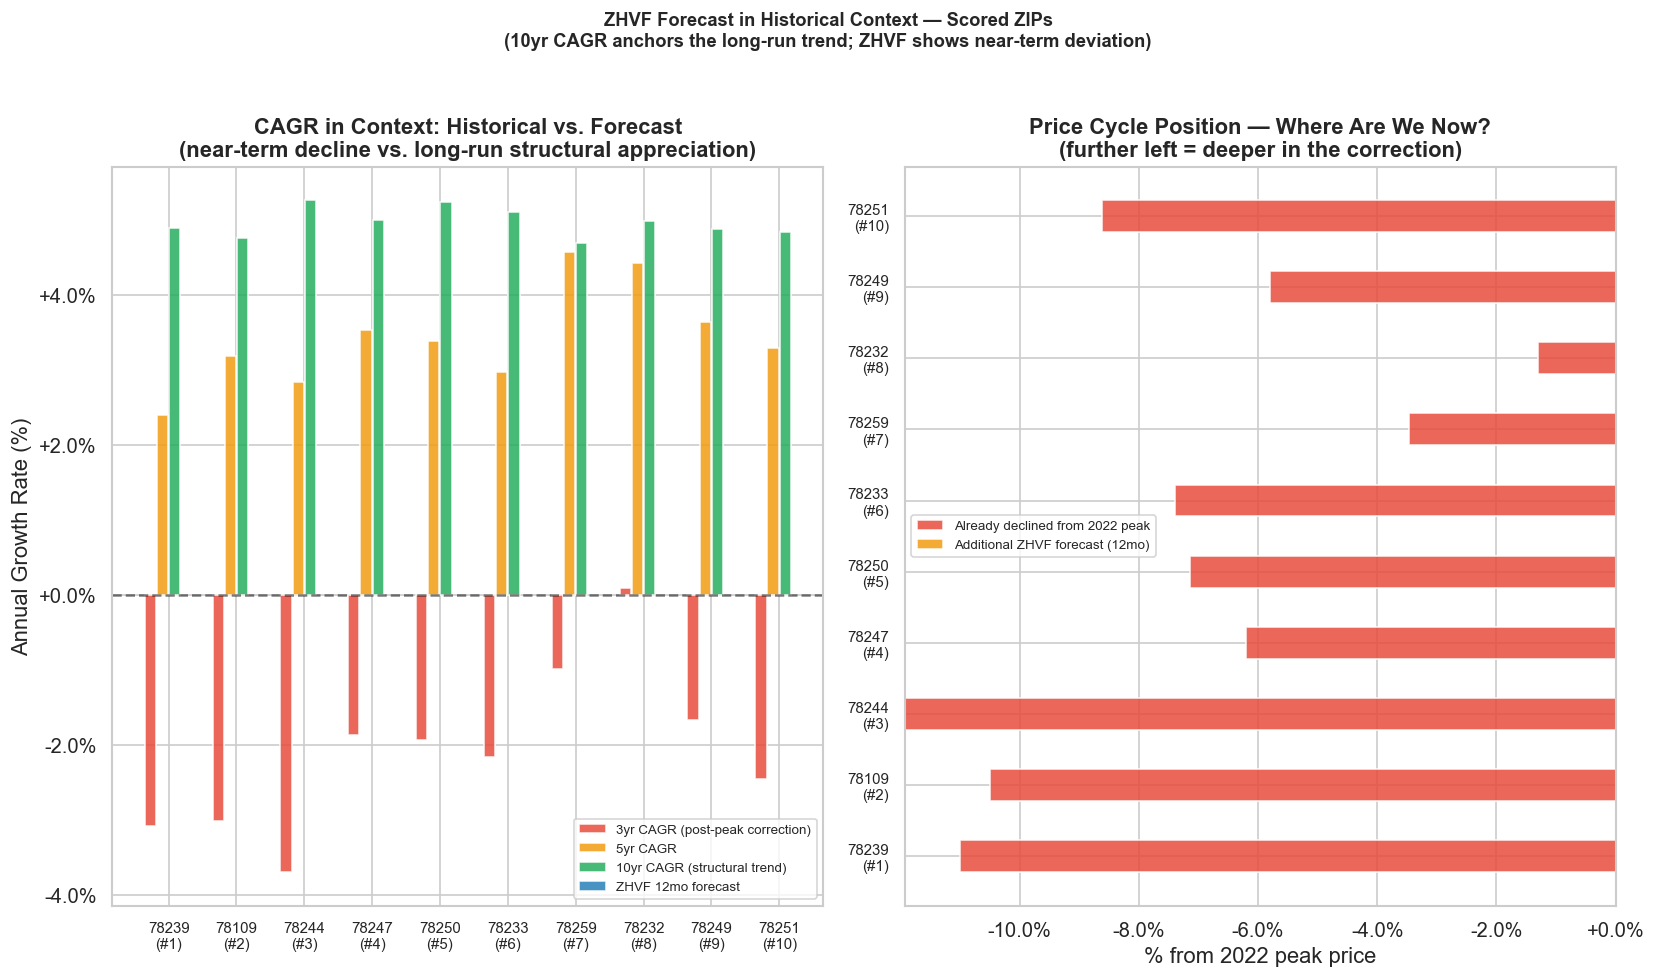

Key reads:
  10yr CAGR is the signal for long-term equity — ranges 4.7% – 5.3% across scored ZIPs.
  Deepest correction: 78244 at -11.9% below its 5yr peak.
  Shallowest correction: 78232 at -1.3% below its 5yr peak.
  ZIPs further into their correction have more recovery upside — but verify with ground truth.


In [ ]:
# ── CAGR context + cycle position ─────────────────────────────────────────────
# Left:  grouped bar — 3yr/5yr/10yr CAGR and ZHVF 12mo for each ZIP.
#        Contextualizes whether the forecast decline is unusual vs. long history.
# Right: horizontal stacked bar — already-fallen from peak + ZHVF additional decline.
#        Shows where each ZIP sits in the correction cycle.

cagr_df = pd.DataFrame(eda_rows).set_index('zip').sort_values('rank')

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(cagr_df) * 0.7 + 1)))

# ── Left: CAGR comparison ──────────────────────────────────────────────────────
ax = axes[0]
metrics = [
    ('3',    FAIL_COLOR,    '3yr CAGR (post-peak correction)'),
    ('5',    WARN_COLOR,    '5yr CAGR'),
    ('10',   PASS_COLOR,    '10yr CAGR (structural trend)'),
    ('zhvf_12', NEUTRAL_COLOR, 'ZHVF 12mo forecast'),
]
n_m    = len(metrics)
y      = np.arange(len(cagr_df))
width  = 0.18
offs   = np.linspace(-(n_m-1)*width/2, (n_m-1)*width/2, n_m)

for j, (key, color, label) in enumerate(metrics):
    col = key if key == 'zhvf_12' else int(key)
    vals = [r.get(col, float('nan')) for r in eda_rows]
    ax.bar(y + offs[j], vals, width=width*0.92, label=label,
           color=color, alpha=0.85, edgecolor='white')

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ax.set_xticks(y)
ax.set_xticklabels(
    [f"{r['zip']}\n(#{r['rank']:.0f})" for r in eda_rows], fontsize=9
)
ax.set_ylabel('Annual Growth Rate (%)')
ax.set_title(
    'CAGR in Context: Historical vs. Forecast\n'
    '(near-term decline vs. long-run structural appreciation)',
    fontweight='bold'
)
ax.legend(fontsize=8, loc='lower right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.1f}%'))

# ── Right: Cycle position ──────────────────────────────────────────────────────
ax2 = axes[1]
already = [-r['pct_below_peak'] for r in eda_rows]   # neg = already declined
more    = [r['zhvf_12'] for r in eda_rows]            # ZHVF (neg = more decline)

ax2.barh(y, already, height=0.45, color=FAIL_COLOR,    alpha=0.85,
         label='Already declined from 2022 peak')
ax2.barh(y, more, height=0.45, left=already, color=WARN_COLOR, alpha=0.85,
         label='Additional ZHVF forecast (12mo)')

# Annotate total decline
for i, (a, m) in enumerate(zip(already, more)):
    total = a + m
    ax2.text(total - 0.15, i, f'{total:.1f}%',
             va='center', ha='right', fontsize=8, fontweight='bold', color='white')

ax2.axvline(0, color='black', linewidth=1.5)
ax2.set_yticks(y)
ax2.set_yticklabels(
    [f"{r['zip']}\n(#{r['rank']:.0f})" for r in eda_rows], fontsize=9
)
ax2.set_xlabel('% from 2022 peak price')
ax2.set_title(
    'Price Cycle Position — Where Are We Now?\n'
    '(further left = deeper in the correction)',
    fontweight='bold'
)
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.1f}%'))

plt.suptitle(
    'ZHVF Forecast in Historical Context — Scored ZIPs\n'
    '(10yr CAGR anchors the long-run trend; ZHVF shows near-term deviation)',
    fontsize=11, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print("Key reads:")
print(f"  10yr CAGR is the signal for long-term equity — ranges "
      f"{min(r.get(10, 0) for r in eda_rows):.1f}% – "
      f"{max(r.get(10, 0) for r in eda_rows):.1f}% across scored ZIPs.")
deepest = max(eda_rows, key=lambda r: r['pct_below_peak'])
shallowest = min(eda_rows, key=lambda r: r['pct_below_peak'])
print(f"  Deepest correction: {deepest['zip']} at -{deepest['pct_below_peak']:.1f}% below its 5yr peak.")
print(f"  Shallowest correction: {shallowest['zip']} at -{shallowest['pct_below_peak']:.1f}% below its 5yr peak.")
print(f"  ZIPs further into their correction have more recovery upside — but verify with ground truth.")